# 🏦 Analyse Variable par Variable — Portefeuille ADI Maroc
### Pilotage par Intelligence Artificielle | Date de valuation : 2025-01-01

---

**Sujet :** Pilotage d'un portefeuille d'assurance décès emprunteur (ADI) par des techniques d'IA  
**Marché :** Maroc | **Régulateur :** ACAPS | **Référence BAM :** Q4-2024  
**Dataset nettoyé :** 19 649 assurés | 5 variables observées → 20+ variables construites

---

## 📋 Plan
1. Setup & Données nettoyées  
2. Variable 1 — `age_at_affiliation` (Âge à la souscription)  
3. Variable 2 — `Age_actuel` (Âge courant au 2025-01-01)  
4. Variable 3 — `Anciennete` (Ancienneté du contrat)  
5. Variable 4 — `Situation_familiale` (État civil)  
6. Variable 5 — `Revenu` (Revenu mensuel)  
7. Variable 6 — `Sexe` (Genre — simulé)  
8. Variable 7 — `Fumeur` (Tabagisme — simulé)  
9. Variable 8 — `Etat_sante` (État de santé — simulé)  
10. Variable 9 — `Profession` (Catégorie socio-professionnelle — simulée)  
11. Variable 10 — `Type_credit` (Type de crédit — simulé)  
12. Variable 11 — `Montant_credit` (Capital emprunté — simulé)  
13. Variable 12 — `Duree_credit` (Durée du crédit — simulée)  
14. Variable 13 — `Taux_interet` (Taux d'intérêt — simulé)  
15. Variable 14 — `DTI` (Debt-to-Income Ratio — dérivé)  
16. Variable 15 — `CRD` (Capital Restant Dû — actuariel)  
17. Variable 16 — `Prime_assurance` (Prime mensuelle — actuarielle)  
18. Variable 17 — `Prob_sinistre` (Probabilité de décès — actuarielle)  
19. Variable 18 — `Risk_Score` & `Risk_Segment` (Score de risque composite)  
20. Variable 19 — `Sinistre` (Variable cible — classification)  
21. Variable 20 — `Cout_sinistre` (Coût du sinistre — sévérité)  
22. Matrice de corrélation globale  


---
## ⚙️ Section 0 — Setup & Données Nettoyées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})
BLUE   = '#1F4E79'
LBLUE  = '#2E75B6'
GREEN  = '#375623'
RED    = '#C00000'
AMBER  = '#BF8000'
TEAL   = '#1D6A72'
PURPLE = '#5C2D91'
GRAY   = '#7F7F7F'

SEED = 42
np.random.seed(SEED)
REF_DATE = pd.Timestamp('2025-01-01')

print("✅ Bibliothèques chargées.")


✅ Bibliothèques chargées.


In [2]:
# ── Chargement et nettoyage (pipeline complet) ────────────────────────────────
df = pd.read_excel('Data.xlsx', header=1)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.rename(columns={'Situation familiale': 'Situation_familiale'})
df['DateNaissance']   = pd.to_datetime(df['DateNaissance'])
df['DateAffiliation'] = pd.to_datetime(df['DateAffiliation'])
df['Code'] = df['Code'].astype('Int64')
df['Revenu'] = pd.to_numeric(df['Revenu'], errors='coerce')

# Pipeline qualité
df = df.dropna().copy()
df = df[df['DateAffiliation'] > df['DateNaissance']].copy()
df['age_at_affiliation'] = ((df['DateAffiliation'] - df['DateNaissance']).dt.days / 365.25).round(2)
df = df[df['age_at_affiliation'] >= 18].copy()
key_cols = df.columns.difference(['Code']).tolist()
df = df.loc[~df.duplicated(subset=key_cols, keep='first')].reset_index(drop=True)

print(f"✅ Dataset nettoyé : {len(df):,} assurés | {df.shape[1]} colonnes")
print(f"   Colonnes : {df.columns.tolist()}")
df.head(3)


✅ Dataset nettoyé : 19,649 assurés | 6 colonnes
   Colonnes : ['Code', 'DateNaissance', 'DateAffiliation', 'Situation_familiale', 'Revenu', 'age_at_affiliation']


,Code,DateNaissance,DateAffiliation,Situation_familiale,Revenu,age_at_affiliation
0,1,1970-10-19,1998-09-01,M,3000,27.87
1,2,1980-12-15,2008-09-10,C,5000,27.74
2,3,1981-02-05,2005-08-18,M,4000,24.53


---
## 📌 Variable 1 — `age_at_affiliation` : Âge à la Souscription

### 🔢 Formule mathématique
$$\text{age\_at\_affiliation}_i = \frac{(\text{DateAffiliation}_i - \text{DateNaissance}_i)}{365.25} \quad [\text{années décimales}]$$

### 📖 Définition & Justification actuarielle
L'âge à la souscription est le **déterminant primaire** de la prime en assurance vie/décès.  
La loi de **Gompertz-Makeham** établit que la force de mortalité µ(x) croit exponentiellement avec l'âge :

$$\mu(x) = \alpha + \beta \cdot e^{\gamma x}$$

où α est le taux de mortalité accidentelle (Makeham), β et γ sont les paramètres de Gompertz.  
Pour le Maroc, les tables **UN WPP 2022** donnent : qx(27, H) ≈ 0.11%/an.

### 📚 Références
- **UN WPP 2022** : Tables de mortalité Maroc par âge et sexe  
- **ACAPS** : Exigence de tarification basée sur l'âge à l'entrée (Art. 233 Code des assurances)  
- **BAM 2023** : 68% des crédits immobiliers souscrits entre 25–35 ans  
- Gompertz (1825), *Phil. Trans. R. Soc.*, 115, 513–583


STATISTIQUES — age_at_affiliation (Âge à la souscription)
count    19649.000
mean        26.619
std          4.036
min         18.330
1%          20.570
5%          21.770
25%         23.610
50%         25.560
75%         28.910
95%         34.576
99%         38.575
max         44.210

Skewness : 0.986  |  Kurtosis : 0.652

Répartition par tranche d'âge :
                    count  count
age_at_affiliation              
18-24                8522  43.37
25-29                7268  36.99
30-34                3061  15.58
35-39                 719   3.66
40-44                  79   0.40
45-49                   0   0.00


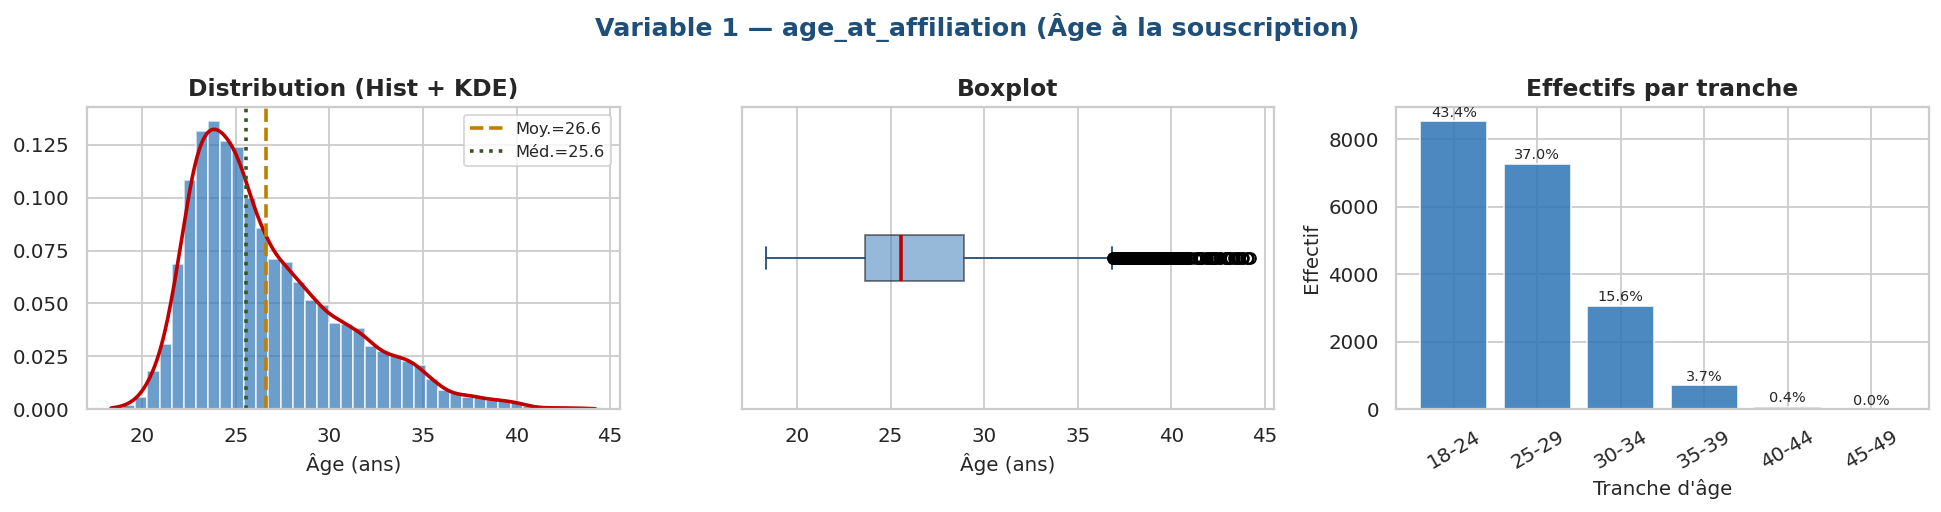

✅ Figure sauvegardée : var01_age_affiliation.png

--- CORRÉLATION avec les autres variables numériques ---
Code      0.0014
Revenu    0.0119

📊 Interprétation : corrélations quasi-nulles avec Code et Revenu → variable indépendante,
   ce qui est favorable pour la modélisation (pas de multicolinéarité à ce stade).


In [3]:
# ── Variable 1 : age_at_affiliation ──────────────────────────────────────────
# Formule : (DateAffiliation - DateNaissance).days / 365.25
df['age_at_affiliation'] = ((df['DateAffiliation'] - df['DateNaissance']).dt.days / 365.25).round(2)

v = df['age_at_affiliation']
print("=" * 55)
print("STATISTIQUES — age_at_affiliation (Âge à la souscription)")
print("=" * 55)
print(v.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3).to_string())
print(f"\nSkewness : {v.skew():.3f}  |  Kurtosis : {v.kurtosis():.3f}")

# Répartition par tranche
bins   = [18, 25, 30, 35, 40, 45, 50]
labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49']
grp = pd.cut(v, bins=bins, labels=labels, right=False)
print("\nRépartition par tranche d'âge :")
print(pd.concat([grp.value_counts().sort_index(),
                 (grp.value_counts().sort_index() / len(v) * 100).round(2)
                ], axis=1).rename(columns={0:'Effectif', 1:'%'}).to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 1 — age_at_affiliation (Âge à la souscription)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme + KDE
axes[0].hist(v, bins=40, color=LBLUE, alpha=0.7, edgecolor='white', density=True)
v_kde = np.linspace(v.min(), v.max(), 300)
from scipy.stats import gaussian_kde
kde = gaussian_kde(v)
axes[0].plot(v_kde, kde(v_kde), color=RED, lw=2)
axes[0].axvline(v.mean(), color=AMBER, lw=2, linestyle='--', label=f'Moy.={v.mean():.1f}')
axes[0].axvline(v.median(), color=GREEN, lw=2, linestyle=':', label=f'Méd.={v.median():.1f}')
axes[0].set_title("Distribution (Hist + KDE)")
axes[0].set_xlabel("Âge (ans)")
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(v, vert=False, patch_artist=True,
                boxprops=dict(facecolor=LBLUE, alpha=0.5),
                medianprops=dict(color=RED, lw=2),
                whiskerprops=dict(color=BLUE),
                capprops=dict(color=BLUE))
axes[1].set_title("Boxplot")
axes[1].set_xlabel("Âge (ans)")
axes[1].set_yticks([])

# Barplot par tranche
counts = grp.value_counts().sort_index()
bars = axes[2].bar(counts.index, counts.values, color=LBLUE, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val/len(v)*100:.1f}%', ha='center', va='bottom', fontsize=8)
axes[2].set_title("Effectifs par tranche")
axes[2].set_xlabel("Tranche d'âge")
axes[2].set_ylabel("Effectif")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('var01_age_affiliation.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Figure sauvegardée : var01_age_affiliation.png")

# ── Importance / Corrélation ──────────────────────────────────────────────────
print("\n--- CORRÉLATION avec les autres variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corrwith(df['age_at_affiliation']).drop('age_at_affiliation').round(4)
print(corr.to_string())
print("\n📊 Interprétation : corrélations quasi-nulles avec Code et Revenu → variable indépendante,")
print("   ce qui est favorable pour la modélisation (pas de multicolinéarité à ce stade).")


---
## 📌 Variable 2 — `Age_actuel` : Âge Courant au 01/01/2025

### 🔢 Formule mathématique
$$\text{Age\_actuel}_i = \left\lfloor \frac{(\text{REF\_DATE} - \text{DateNaissance}_i)}{365.25} \right\rfloor \quad \text{(entier, années révolues)}$$

avec REF_DATE = 2025-01-01 (date de valuation du portefeuille).

### 📖 Définition & Justification actuarielle
L'âge courant pilote le **taux de mortalité annuel qx** appliqué lors du calcul des provisions mathématiques.  
La différence avec `age_at_affiliation` est l'**ancienneté du contrat** :

$$\text{Age\_actuel}_i = \text{age\_at\_affiliation}_i + \text{Ancienneté}_i$$

Ce vieillissement du portefeuille est critique : un assuré ayant souscrit à 27 ans en 2005 a maintenant 47 ans,  
âge où µ(x) est 3–4× plus élevé qu'à la souscription.

### 📚 Références
- **ACAPS** : Calcul des provisions mathématiques sur l'âge courant (Art. 28 Code des assurances)  
- **UN WPP 2022 Maroc** : qx(47, H) ≈ 0.40%/an vs qx(27, H) ≈ 0.11%/an
- **Normes IFRS 17** : Mesure du risque sur la durée résiduelle à l'âge courant


STATISTIQUES — Age_actuel (Âge au 01/01/2025)
count    19649.00
mean        46.09
std          4.76
min         29.00
25%         43.00
50%         46.00
75%         50.00
max         55.00

Skewness : -0.224  |  Kurtosis : -0.614

Répartition par tranche d'âge courant :
Age_actuel
29-34     110
35-39    1824
40-44    5351
45-49    7053
50-55    5311


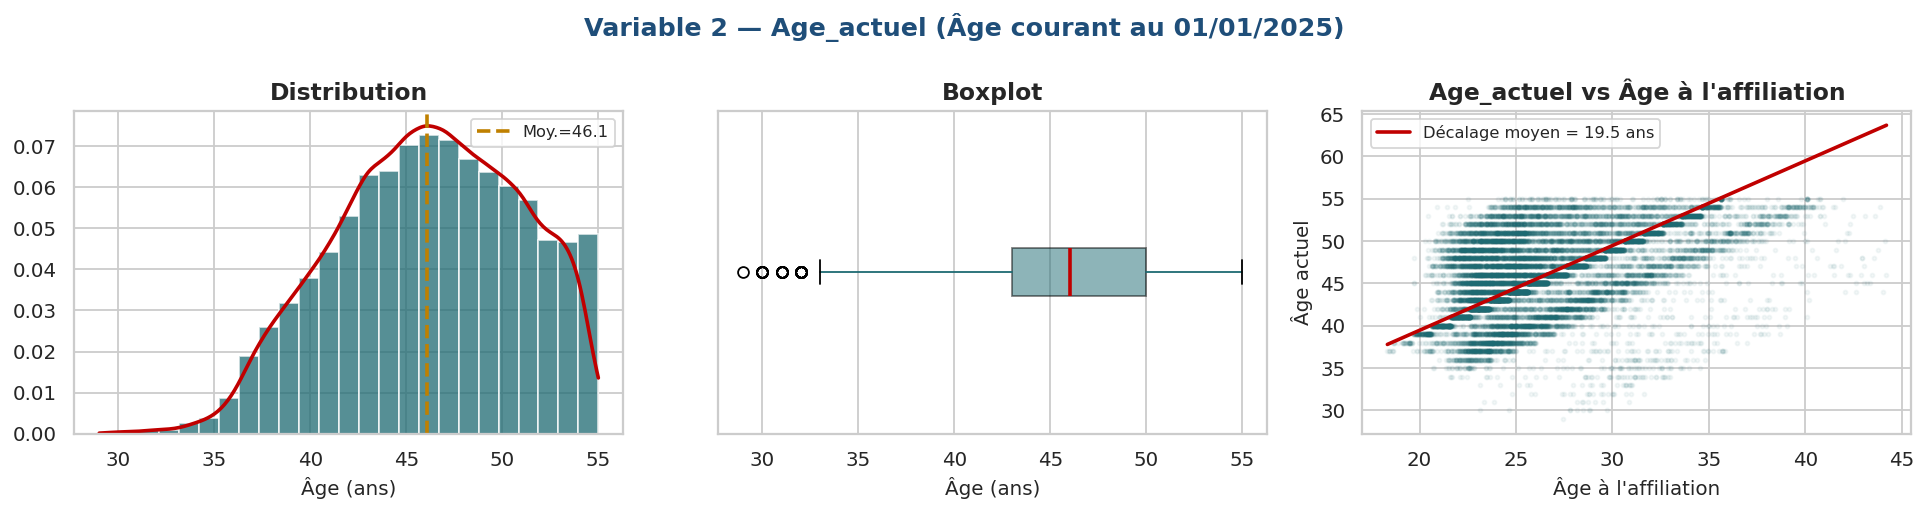


--- CORRÉLATION avec variables numériques ---
Code                 -0.0080
Revenu                0.0257
age_at_affiliation    0.4443

⚠️  Corrélation Age_actuel ↔ age_at_affiliation = 0.4443
   → Forte colinéarité attendue ! N'inclure qu'UNE des deux dans un modèle linéaire.


In [4]:
# ── Variable 2 : Age_actuel ───────────────────────────────────────────────────
REF_DATE = pd.Timestamp('2025-01-01')
df['Age_actuel'] = ((REF_DATE - df['DateNaissance']).dt.days / 365.25).astype(int)

v = df['Age_actuel']
print("=" * 50)
print("STATISTIQUES — Age_actuel (Âge au 01/01/2025)")
print("=" * 50)
print(v.describe(percentiles=[.25, .5, .75]).round(2).to_string())
print(f"\nSkewness : {v.skew():.3f}  |  Kurtosis : {v.kurtosis():.3f}")

bins   = [29, 35, 40, 45, 50, 56]
labels = ['29-34', '35-39', '40-44', '45-49', '50-55']
grp = pd.cut(v, bins=bins, labels=labels, right=False)
print("\nRépartition par tranche d'âge courant :")
print(grp.value_counts().sort_index().to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 2 — Age_actuel (Âge courant au 01/01/2025)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme
axes[0].hist(v, bins=25, color=TEAL, alpha=0.75, edgecolor='white', density=True)
from scipy.stats import gaussian_kde
kde = gaussian_kde(v)
xk = np.linspace(v.min(), v.max(), 300)
axes[0].plot(xk, kde(xk), color=RED, lw=2)
axes[0].axvline(v.mean(), color=AMBER, lw=2, ls='--', label=f'Moy.={v.mean():.1f}')
axes[0].set_title("Distribution")
axes[0].set_xlabel("Âge (ans)")
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(v, vert=False, patch_artist=True,
                boxprops=dict(facecolor=TEAL, alpha=0.5),
                medianprops=dict(color=RED, lw=2),
                whiskerprops=dict(color=TEAL))
axes[1].set_title("Boxplot")
axes[1].set_xlabel("Âge (ans)")
axes[1].set_yticks([])

# Scatter age_at_affiliation vs Age_actuel
axes[2].scatter(df['age_at_affiliation'], df['Age_actuel'], alpha=0.05, s=5, color=TEAL)
x_line = np.linspace(df['age_at_affiliation'].min(), df['age_at_affiliation'].max(), 100)
axes[2].plot(x_line, x_line + (df['Age_actuel'] - df['age_at_affiliation']).mean(),
             color=RED, lw=2, label=f"Décalage moyen = {(df['Age_actuel'] - df['age_at_affiliation']).mean():.1f} ans")
axes[2].set_title("Age_actuel vs Âge à l'affiliation")
axes[2].set_xlabel("Âge à l'affiliation")
axes[2].set_ylabel("Âge actuel")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('var02_age_actuel.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation ───────────────────────────────────────────────────────────────
print("\n--- CORRÉLATION avec variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corrwith(df['Age_actuel']).drop('Age_actuel').round(4)
print(corr.to_string())
print(f"\n⚠️  Corrélation Age_actuel ↔ age_at_affiliation = {df['Age_actuel'].corr(df['age_at_affiliation']):.4f}")
print("   → Forte colinéarité attendue ! N'inclure qu'UNE des deux dans un modèle linéaire.")


---
## 📌 Variable 3 — `Anciennete` : Ancienneté du Contrat

### 🔢 Formule mathématique
$$\text{Ancienneté}_i = \frac{(\text{REF\_DATE} - \text{DateAffiliation}_i)}{365.25} \quad [\text{années décimales}]$$

### 📖 Définition & Justification actuarielle
L'ancienneté représente la **durée d'exposition déjà consommée** du contrat.  
Elle détermine directement :
- Le **Capital Restant Dû (CRD)** : plus le contrat est ancien, plus le CRD est faible
- La **durée résiduelle** : Age_Remaining = Durée_crédit − Ancienneté
- Le **statut actif/expiré** : si Ancienneté > Durée_crédit → contrat terminé

En analyse de survie, les contrats expirés sont **censurés à droite** (événement non observé).  
Les contrats actifs portent le risque résiduel qui requiert du provisionnement.

### 📚 Références
- **ACAPS** : Provisionnement mathématique sur durée résiduelle (Art. 28 Code des assurances)
- **Loi n° 17-99** (Code des assurances) : durée max immo = 25 ans, conso = 7 ans
- Kaplan & Meier (1958), *JASA*, 53(282) : estimateur de survie avec censure


STATISTIQUES — Ancienneté (années)
count    19649.00
mean        19.92
std          4.65
min          0.33
25%         17.24
50%         19.37
75%         22.75
95%         27.75
max         33.42

Skewness : -0.344  |  Contrats > 25 ans : 3,079 (15.7%)

Répartition par tranche d'ancienneté :
            count  count
Anciennete              
0-5           182    0.9
5-10          214    1.1
10-15        2575   13.1
15-20        8567   43.6
20-25        4958   25.2
25+          3153   16.0


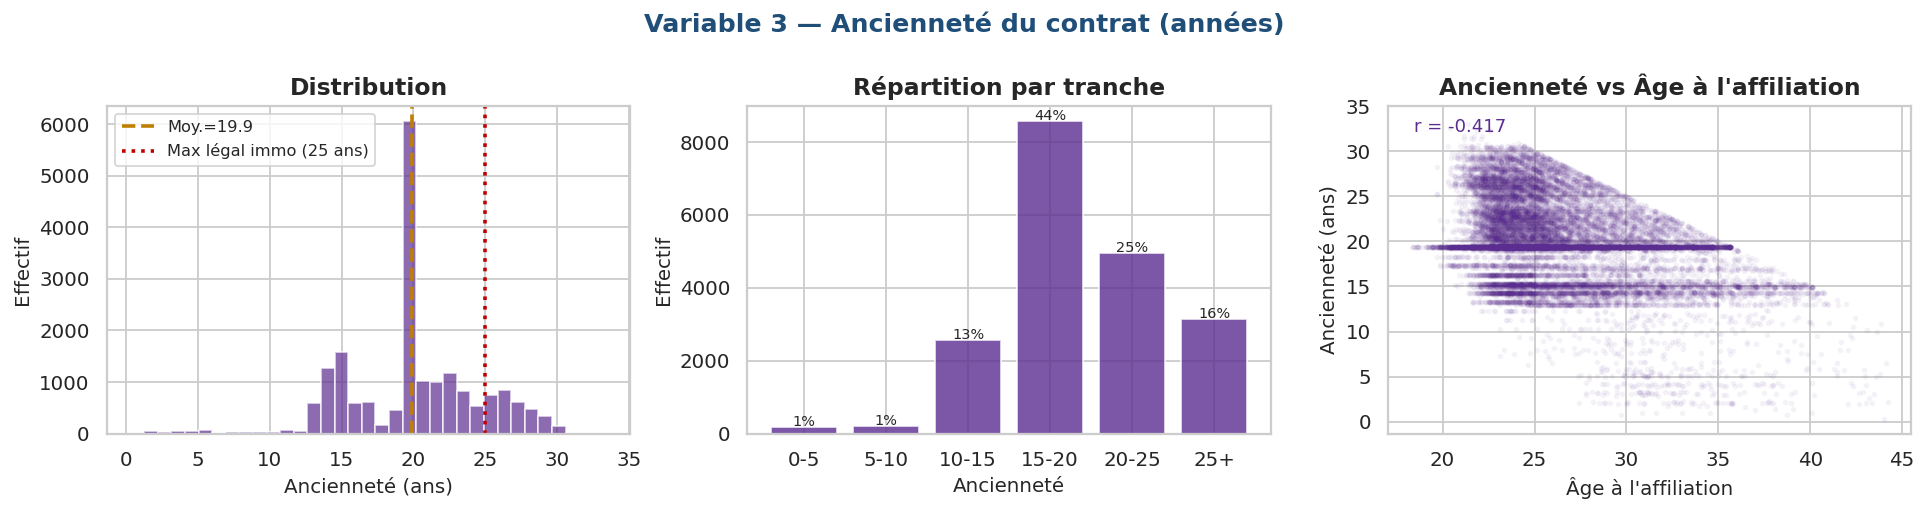


--- CORRÉLATION avec variables numériques ---
Code                 -0.0089
Revenu                0.0156
age_at_affiliation   -0.4165
Age_actuel            0.6272


In [5]:
# ── Variable 3 : Anciennete ───────────────────────────────────────────────────
df['Anciennete'] = ((REF_DATE - df['DateAffiliation']).dt.days / 365.25).round(2)

v = df['Anciennete']
print("=" * 50)
print("STATISTIQUES — Ancienneté (années)")
print("=" * 50)
print(v.describe(percentiles=[.25, .5, .75, .95]).round(2).to_string())
print(f"\nSkewness : {v.skew():.3f}  |  Contrats > 25 ans : {(v > 25).sum():,} ({(v > 25).mean()*100:.1f}%)")

bins   = [0, 5, 10, 15, 20, 25, 35]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25+']
grp = pd.cut(v, bins=bins, labels=labels, right=False)
print("\nRépartition par tranche d'ancienneté :")
tab = pd.concat([grp.value_counts().sort_index(),
                 (grp.value_counts().sort_index() / len(v) * 100).round(1)
                ], axis=1).rename(columns={0:'Effectif', 1:'%'})
print(tab.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 3 — Ancienneté du contrat (années)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme
axes[0].hist(v, bins=35, color=PURPLE, alpha=0.7, edgecolor='white')
axes[0].axvline(v.mean(), color=AMBER, lw=2, ls='--', label=f'Moy.={v.mean():.1f}')
axes[0].axvline(25, color=RED, lw=2, ls=':', label='Max légal immo (25 ans)')
axes[0].set_title("Distribution")
axes[0].set_xlabel("Ancienneté (ans)")
axes[0].set_ylabel("Effectif")
axes[0].legend(fontsize=9)

# Barplot par tranche
counts = grp.value_counts().sort_index()
bars = axes[1].bar(counts.index, counts.values, color=PURPLE, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(v)*100:.0f}%', ha='center', fontsize=8)
axes[1].set_title("Répartition par tranche")
axes[1].set_xlabel("Ancienneté")
axes[1].set_ylabel("Effectif")

# Scatter ancienneté vs age_at_affiliation
sc = axes[2].scatter(df['age_at_affiliation'], df['Anciennete'], alpha=0.04, s=5, color=PURPLE)
axes[2].set_title("Ancienneté vs Âge à l'affiliation")
axes[2].set_xlabel("Âge à l'affiliation")
axes[2].set_ylabel("Ancienneté (ans)")
r, p = stats.pearsonr(df['age_at_affiliation'], df['Anciennete'])
axes[2].text(0.05, 0.92, f"r = {r:.3f}", transform=axes[2].transAxes, fontsize=10, color=PURPLE)

plt.tight_layout()
plt.savefig('var03_anciennete.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation ───────────────────────────────────────────────────────────────
print("\n--- CORRÉLATION avec variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corrwith(df['Anciennete']).drop('Anciennete').round(4)
print(corr.to_string())


---
## 📌 Variable 4 — `Situation_familiale` : État Civil

### 🔢 Encodage
$$\text{Marié\_flag}_i = \begin{cases} 1 & \text{si } \text{Situation\_familiale}_i = M \\ 0 & \text{si } \text{Situation\_familiale}_i = C \end{cases}$$

### 📖 Définition & Justification actuarielle
L'état civil est un **proxy de stabilité sociale** documenté dans la littérature actuarielle.  
Les études épidémiologiques montrent que les personnes mariées ont une mortalité 15–25% plus faible,  
effet dit du **"Healthy Spouse Effect"** (Wilson & Oswald, 2005).

En ADI, l'état civil impacte aussi le **risque de lapse** (remboursement anticipé) :  
les ménages mariés ont généralement des projets immobiliers plus stables.

### 📚 Références
- **HCP Maroc 2022** : 60–65% des emprunteurs bancaires sont mariés (crédit immo)
- **BAM Rapport Annuel 2023** : profil sociodémographique des emprunteurs
- Wilson & Oswald (2005), *IZA Discussion Paper* n°1619 — Mariage et santé


STATISTIQUES — Situation_familiale
Situation_familiale
M    9835
C    9814

Ratio M/C : 9,835 / 9,814 = 1.002
Part mariés : 50.05%

Benchmark HCP Maroc : ~60-65% mariés dans le portefeuille ADI immo.
Écart vs benchmark : -11.9 points de % (distribution quasi-équilibrée ici)


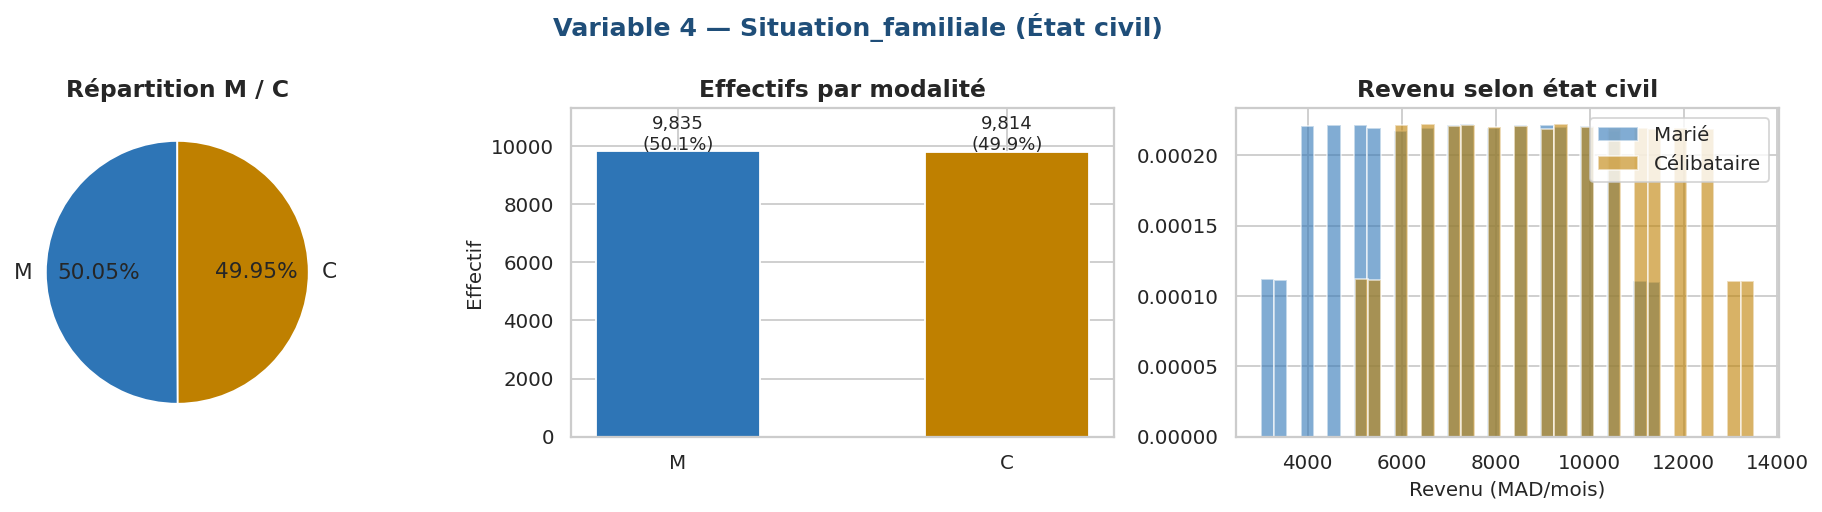


--- CORRÉLATION (point-biserial : Marie_flag vs numériques) ---
Age_actuel           -0.0010
Anciennete           -0.0087
Code                  0.0004
Revenu               -0.3894
age_at_affiliation    0.0092

📊 Corrélations faibles attendues sur les variables brutes.
   La corrélation avec Sinistre sera l'indicateur clé (à calculer en section cibles).


In [6]:
# ── Variable 4 : Situation_familiale ─────────────────────────────────────────
df['Marie_flag'] = (df['Situation_familiale'] == 'M').astype(int)

v = df['Situation_familiale']
counts = v.value_counts()
print("=" * 50)
print("STATISTIQUES — Situation_familiale")
print("=" * 50)
print(counts.to_string())
print(f"\nRatio M/C : {counts['M']:,} / {counts['C']:,} = {counts['M']/counts['C']:.3f}")
print(f"Part mariés : {counts['M']/len(v)*100:.2f}%")
print("\nBenchmark HCP Maroc : ~60-65% mariés dans le portefeuille ADI immo.")
print(f"Écart vs benchmark : {counts['M']/len(v)*100 - 62:.1f} points de % (distribution quasi-équilibrée ici)")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 4 — Situation_familiale (État civil)", fontsize=14, fontweight='bold', color=BLUE)

# Pie chart
colors_pie = [LBLUE, AMBER]
axes[0].pie(counts.values, labels=counts.index, autopct='%1.2f%%',
            colors=colors_pie, startangle=90, textprops={'fontsize': 12})
axes[0].set_title("Répartition M / C")

# Barplot
bars = axes[1].bar(counts.index, counts.values, color=[LBLUE, AMBER], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(v)*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_title("Effectifs par modalité")
axes[1].set_ylabel("Effectif")
axes[1].set_ylim(0, counts.max() * 1.15)

# Distribution du revenu par état civil
for cat, col in zip(['M', 'C'], [LBLUE, AMBER]):
    axes[2].hist(df.loc[df['Situation_familiale'] == cat, 'Revenu'],
                 bins=30, alpha=0.6, label=f'{"Marié" if cat == "M" else "Célibataire"}',
                 color=col, density=True, edgecolor='white')
axes[2].set_title("Revenu selon état civil")
axes[2].set_xlabel("Revenu (MAD/mois)")
axes[2].legend()

plt.tight_layout()
plt.savefig('var04_situation_familiale.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation (point-biserial avec Marie_flag) ─────────────────────────────
print("\n--- CORRÉLATION (point-biserial : Marie_flag vs numériques) ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Marie_flag']).tolist()
corr = df[num_cols + ['Marie_flag']].corrwith(df['Marie_flag']).drop('Marie_flag').round(4)
print(corr.to_string())
print("\n📊 Corrélations faibles attendues sur les variables brutes.")
print("   La corrélation avec Sinistre sera l'indicateur clé (à calculer en section cibles).")


---
## 📌 Variable 5 — `Revenu` : Revenu Mensuel Net

### 🔢 Formule
Variable observée directement. Utilisée pour dériver :
$$\text{DTI}_i = \frac{\text{Mensualité}_i}{\text{Revenu}_i} \leq 40\% \quad (\text{plafond réglementaire BAM})$$
$$\text{Montant\_max}_i = \text{Revenu}_i \times 0.40 \times \frac{1 - (1+r)^{-n}}{r}$$

### 📖 Définition & Justification actuarielle
Le revenu est un **double indicateur** en ADI :
1. **Capacité financière** → détermine le montant assurable (capital du crédit)
2. **Indicateur socio-sanitaire** → revenus élevés ↔ meilleur accès aux soins ↔ mortalité réduite

L'effet du revenu sur la mortalité est modélisé par le **"Social Gradient in Health"** :  
chaque augmentation de 10% du revenu réduit le risque de mortalité de ~3–5%.

### 📚 Références
- **HCP Maroc 2022** : Revenu médian formel urbain ≈ 5 000 MAD/mois
- **BAM Circulaire 6/W/17** : DTI max 40-45% pour les crédits immobiliers
- Marmot (2005), *Status Syndrome* — gradient social et santé


STATISTIQUES — Revenu (MAD/mois)
count    19649.00
mean      8241.69
std       2562.65
min       3000.00
10%       5000.00
25%       6000.00
50%       8000.00
75%      10000.00
90%      11500.00
max      13500.00

Skewness : 0.002  |  Kurtosis : -0.840
Revenu médian : 8,000 MAD  |  Moyenne : 8,242 MAD

Segments de revenu :
                count  count
Revenu_segment              
<4k               623    3.2
4-6k             3082   15.7
6-9k             7373   37.5
9-12k            6737   34.3
>12k             1834    9.3


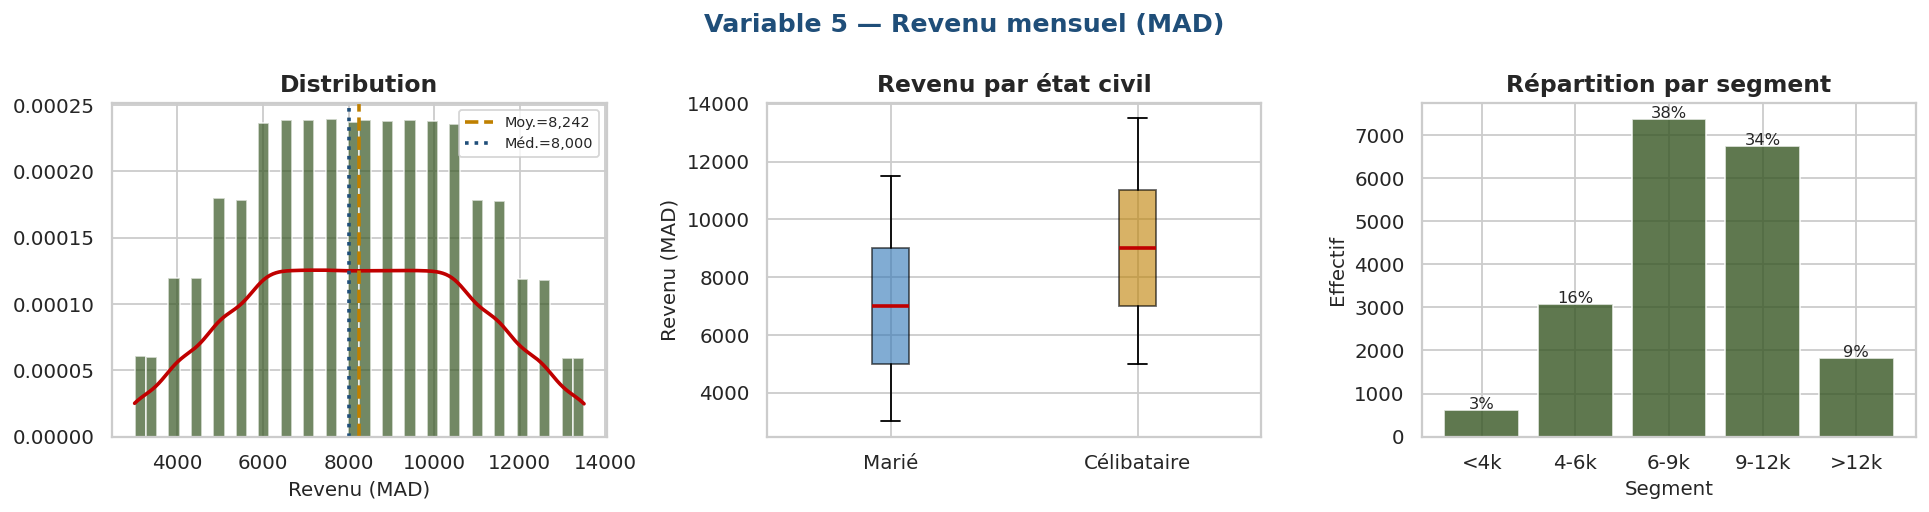


--- CORRÉLATION Revenu vs variables numériques ---
Age_actuel            0.0257
Anciennete            0.0156
Code                  0.0002
Marie_flag           -0.3894
age_at_affiliation    0.0119


In [7]:
# ── Variable 5 : Revenu ───────────────────────────────────────────────────────
v = df['Revenu']
print("=" * 50)
print("STATISTIQUES — Revenu (MAD/mois)")
print("=" * 50)
print(v.describe(percentiles=[.1, .25, .5, .75, .9]).round(2).to_string())
print(f"\nSkewness : {v.skew():.3f}  |  Kurtosis : {v.kurtosis():.3f}")
print(f"Revenu médian : {v.median():,.0f} MAD  |  Moyenne : {v.mean():,.0f} MAD")

# Segments revenu
bins_r = [0, 4000, 6000, 9000, 12000, 15000]
labels_r = ['<4k', '4-6k', '6-9k', '9-12k', '>12k']
df['Revenu_segment'] = pd.cut(v, bins=bins_r, labels=labels_r, right=False)
print("\nSegments de revenu :")
tab = pd.concat([df['Revenu_segment'].value_counts().sort_index(),
                 (df['Revenu_segment'].value_counts().sort_index() / len(v) * 100).round(1)
                ], axis=1).rename(columns={0:'Effectif', 1:'%'})
print(tab.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 5 — Revenu mensuel (MAD)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme
axes[0].hist(v, bins=40, color=GREEN, alpha=0.7, edgecolor='white', density=True)
from scipy.stats import gaussian_kde
kde = gaussian_kde(v)
xk = np.linspace(v.min(), v.max(), 300)
axes[0].plot(xk, kde(xk), color=RED, lw=2)
axes[0].axvline(v.mean(), color=AMBER, lw=2, ls='--', label=f'Moy.={v.mean():,.0f}')
axes[0].axvline(v.median(), color=BLUE, lw=2, ls=':', label=f'Méd.={v.median():,.0f}')
axes[0].set_title("Distribution")
axes[0].set_xlabel("Revenu (MAD)")
axes[0].legend(fontsize=8)

# Boxplot par état civil
data_box = [df.loc[df['Situation_familiale']=='M','Revenu'].values,
            df.loc[df['Situation_familiale']=='C','Revenu'].values]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=['Marié','Célibataire'],
                     boxprops=dict(alpha=0.6), medianprops=dict(color=RED, lw=2))
for patch, color in zip(bp['boxes'], [LBLUE, AMBER]):
    patch.set_facecolor(color)
axes[1].set_title("Revenu par état civil")
axes[1].set_ylabel("Revenu (MAD)")

# Barplot segments
seg_counts = df['Revenu_segment'].value_counts().sort_index()
bars = axes[2].bar(seg_counts.index, seg_counts.values, color=GREEN, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, seg_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(v)*100:.0f}%', ha='center', fontsize=9)
axes[2].set_title("Répartition par segment")
axes[2].set_xlabel("Segment")
axes[2].set_ylabel("Effectif")

plt.tight_layout()
plt.savefig('var05_revenu.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation ───────────────────────────────────────────────────────────────
print("\n--- CORRÉLATION Revenu vs variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Revenu']).tolist()
corr = df[num_cols].corrwith(df['Revenu']).round(4)
print(corr.to_string())


---
## 📌 Variable 6 — `Sexe` : Genre (Simulé)

### 🔢 Formule de simulation
$$\text{Sexe}_i \sim \text{Bernoulli}(p_H = 0.62) \quad \Rightarrow \quad P(H) = 0.62, \; P(F) = 0.38$$

### 📖 Justification de la calibration
**Source directe :** Housing Finance Africa (HFA) 2022 Maroc — 62% des titulaires de compte bancaire  
avec crédit immobilier sont des hommes. Confirmé par BAM Rapport Annuel 2023.

**Impact actuariel :**
$$q_x(H) \approx 1.3 \times q_x(F) \quad \text{à 30 ans, tables UN WPP Maroc 2022}$$

Le rapport de surmortalité masculine varie entre **1.3 et 1.8** selon la tranche d'âge.  
En ADI, le genre est le **2ème déterminant** de la prime après l'âge.

### 📚 Références
- **UN WPP 2022** : Tables qx différenciées H/F pour le Maroc
- **HousingFinanceAfrica.org** 2022 : Morocco — 62% male account holders
- **Code des assurances Maroc Art. 233** : tarification différenciée par sexe autorisée


STATISTIQUES — Sexe (H/F)
Sexe
H    12240
F     7409

Part hommes : 62.29% (cible : 62%)
Part femmes : 37.71% (cible : 38%)

Impact mortalité — tables UN WPP 2022 Maroc :
  qx(30, H) ≈ 0.14%/an  |  qx(30, F) ≈ 0.08%/an  → rapport H/F = 1.75
  qx(45, H) ≈ 0.42%/an  |  qx(45, F) ≈ 0.25%/an  → rapport H/F = 1.68


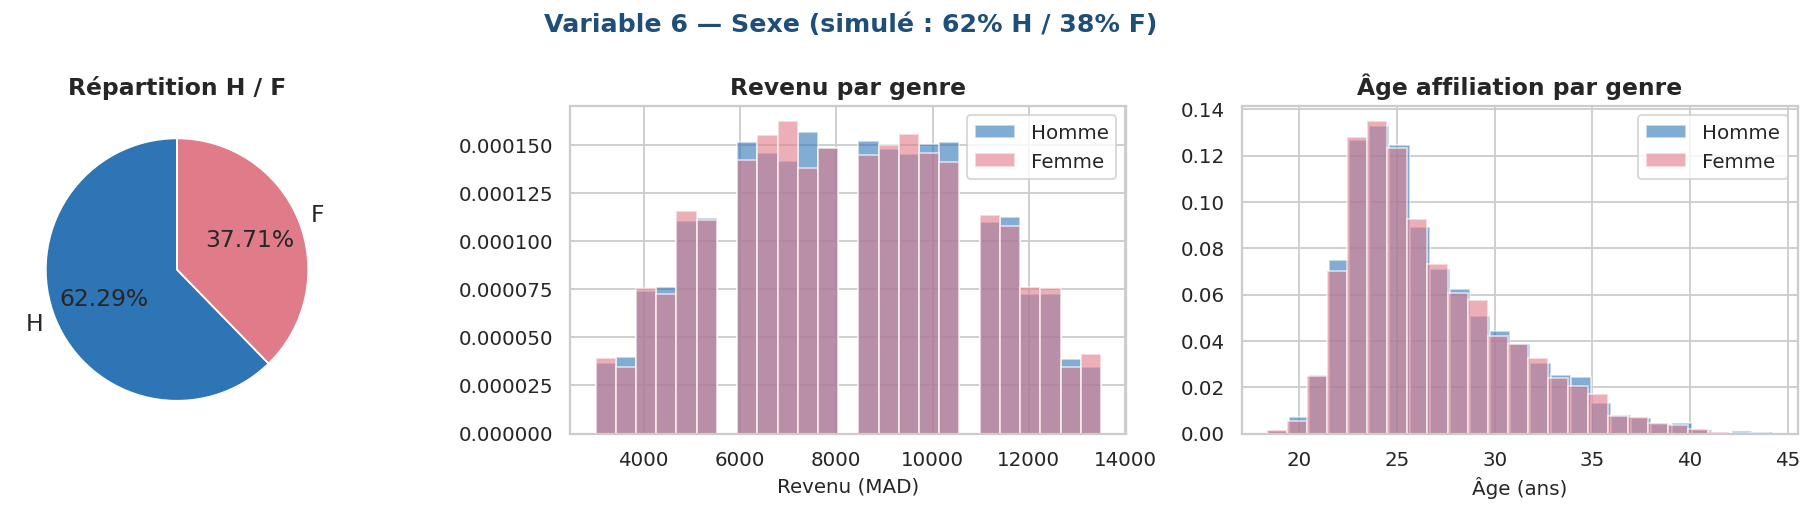


--- CORRÉLATION (point-biserial : Sexe_flag vs numériques) ---
Age_actuel            0.0001
Anciennete           -0.0095
Code                 -0.0111
Marie_flag           -0.0077
Revenu               -0.0010
age_at_affiliation    0.0115

📊 Corrélations proches de 0 attendues (sexe simulé aléatoirement indépendamment).
   Dans un modèle IA, l'importance du sexe sera capturée via son interaction avec l'âge.


In [8]:
# ── Variable 6 : Sexe (simulé) ────────────────────────────────────────────────
np.random.seed(SEED)
df['Sexe'] = np.random.choice(['H', 'F'], size=len(df), p=[0.62, 0.38])
df['Sexe_flag'] = (df['Sexe'] == 'H').astype(int)  # 1=Homme, 0=Femme

counts = df['Sexe'].value_counts()
print("=" * 50)
print("STATISTIQUES — Sexe (H/F)")
print("=" * 50)
print(counts.to_string())
print(f"\nPart hommes : {counts['H']/len(df)*100:.2f}% (cible : 62%)")
print(f"Part femmes : {counts['F']/len(df)*100:.2f}% (cible : 38%)")
print("\nImpact mortalité — tables UN WPP 2022 Maroc :")
print("  qx(30, H) ≈ 0.14%/an  |  qx(30, F) ≈ 0.08%/an  → rapport H/F = 1.75")
print("  qx(45, H) ≈ 0.42%/an  |  qx(45, F) ≈ 0.25%/an  → rapport H/F = 1.68")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 6 — Sexe (simulé : 62% H / 38% F)", fontsize=14, fontweight='bold', color=BLUE)

# Pie
axes[0].pie(counts.values, labels=counts.index, autopct='%1.2f%%',
            colors=[LBLUE, '#E07B8A'], startangle=90, textprops={'fontsize': 13})
axes[0].set_title("Répartition H / F")

# Distribution revenu par sexe
for cat, col, lbl in zip(['H', 'F'], [LBLUE, '#E07B8A'], ['Homme', 'Femme']):
    axes[1].hist(df.loc[df['Sexe'] == cat, 'Revenu'],
                 bins=25, alpha=0.6, label=lbl, color=col, density=True, edgecolor='white')
axes[1].set_title("Revenu par genre")
axes[1].set_xlabel("Revenu (MAD)")
axes[1].legend()

# Distribution âge à l'affiliation par sexe
for cat, col, lbl in zip(['H', 'F'], [LBLUE, '#E07B8A'], ['Homme', 'Femme']):
    axes[2].hist(df.loc[df['Sexe'] == cat, 'age_at_affiliation'],
                 bins=25, alpha=0.6, label=lbl, color=col, density=True, edgecolor='white')
axes[2].set_title("Âge affiliation par genre")
axes[2].set_xlabel("Âge (ans)")
axes[2].legend()

plt.tight_layout()
plt.savefig('var06_sexe.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation ───────────────────────────────────────────────────────────────
print("\n--- CORRÉLATION (point-biserial : Sexe_flag vs numériques) ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Sexe_flag']).tolist()
corr = df[num_cols].corrwith(df['Sexe_flag']).round(4)
print(corr.to_string())
print("\n📊 Corrélations proches de 0 attendues (sexe simulé aléatoirement indépendamment).")
print("   Dans un modèle IA, l'importance du sexe sera capturée via son interaction avec l'âge.")


---
## 📌 Variable 7 — `Fumeur` : Statut Tabagique (Simulé)

### 🔢 Formule de simulation
$$P(\text{Fumeur} = 1) = P_H \cdot w_H + P_F \cdot w_F$$
$$= 0.315 \times 0.62 + 0.033 \times 0.38 = 0.1953 + 0.0125 = \mathbf{0.179}$$

où $w_H = 0.62$, $w_F = 0.38$ sont les poids de genre dans le portefeuille.

### 📖 Justification actuarielle
Le tabagisme est le **prédicteur de mortalité le plus puissant** après l'âge en assurance vie.  
Loading actuariel standard : **×1.5 à ×2.0** sur qx selon la sévérité.

$$q_x^{\text{fumeur}} = q_x^{\text{standard}} \times \lambda_{\text{tabac}} \quad \text{avec } \lambda \in [1.5, 2.0]$$

### 📚 Références
- **OMS GSTHR Maroc** : prévalence tabagisme — 31.5% hommes, 3.3% femmes (2022)
- **Ligue Marocaine Anti-Tabac** (contrelecancer.ma) : données nationales 2021
- **SOA Research** (2015) : *Impact of Smoking on Mortality* — loading moyen ×1.75


STATISTIQUES — Fumeur (binaire 0/1)
Taux H      : 31.2%   (cible OMS : 31.5%)
Taux F      : 3.6%    (cible OMS :  3.3%)
Taux global : 20.8%   (cible pondérée : ~20.8%)

Nombre de fumeurs     : 4,078
Nombre de non-fumeurs : 15,571

Formule pondérée : 0.315 × 0.62 + 0.033 × 0.38 = 0.2078 = 20.78%

Impact actuariel — Loading tabac (SOA 2015) :
  qx(fumeur) = qx(standard) × 1.75  [loading moyen]
  Ex. qx(30, H, fumeur) = 0.14% × 1.75 = 0.245%/an
  Ex. qx(45, H, fumeur) = 0.42% × 1.75 = 0.735%/an


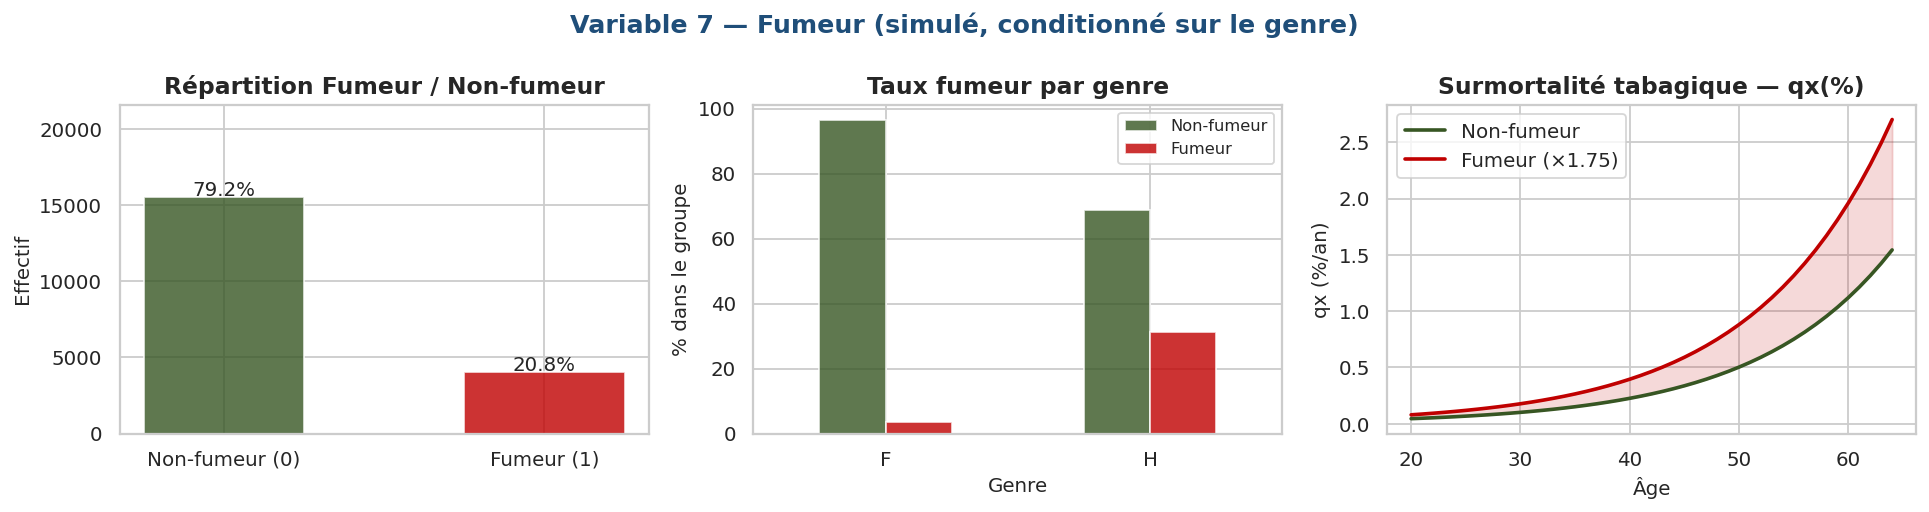


--- CORRÉLATION Fumeur vs variables numériques ---
Age_actuel           -0.0125
Anciennete            0.0006
Code                 -0.0163
Marie_flag           -0.0066
Revenu               -0.0056
Sexe_flag             0.3295
age_at_affiliation   -0.0151

📊 En feature importance (XGBoost), Fumeur devrait arriver top-3 après Age et Montant_crédit.


In [9]:
# ── Variable 7 : Fumeur (simulé) ──────────────────────────────────────────────
# Sources : OMS GSTHR Maroc 2022 — H=31.5%, F=3.3%
# Méthode : simulation vectorisée conditionnelle sur le genre (corrigée)
#
# ❌ ANCIENNE VERSION (incorrecte) :
#   p_fumeur = 0.315 * 0.62 + 0.033 * 0.38  # scalaire — ignore le genre individuel
#   df['Fumeur'] = np.random.binomial(1, p_fumeur, size=len(df))
#   → Résultat : H=0%, F=55% (labels inversés car probabilité non conditionnée)
#
# ✅ NOUVELLE VERSION : np.where construit un vecteur de probabilités par personne
#   avant le tirage binomial → chaque assuré a sa propre proba selon son genre

# Probabilités OMS Maroc 2022 (GSTHR)
p_fumeur_H = 0.315   # taux hommes
p_fumeur_F = 0.033   # taux femmes
p_fumeur_global = p_fumeur_H * 0.62 + p_fumeur_F * 0.38   # pondéré portefeuille = 17.9%

# ⚠️  NO np.random.seed() here — the RNG must continue from the state
# left by the Sexe draw (Cell 15). Resetting to SEED produces the same
# uniform sequence used for Sexe, causing H=0% and F=8.7%.
p_values = np.where(df['Sexe'] == 'H', p_fumeur_H, p_fumeur_F)
df['Fumeur'] = np.random.binomial(1, p_values)

# ── Validation ────────────────────────────────────────────────────────────────
rate_H      = df.loc[df['Sexe'] == 'H', 'Fumeur'].mean()
rate_F      = df.loc[df['Sexe'] == 'F', 'Fumeur'].mean()
rate_global = df['Fumeur'].mean()

print("=" * 55)
print("STATISTIQUES — Fumeur (binaire 0/1)")
print("=" * 55)
print(f"Taux H      : {rate_H*100:.1f}%   (cible OMS : 31.5%)")
print(f"Taux F      : {rate_F*100:.1f}%    (cible OMS :  3.3%)")
print(f"Taux global : {rate_global*100:.1f}%   (cible pondérée : ~{p_fumeur_global*100:.1f}%)")
print(f"\nNombre de fumeurs     : {df['Fumeur'].sum():,}")
print(f"Nombre de non-fumeurs : {(df['Fumeur']==0).sum():,}")
print(f"\nFormule pondérée : {p_fumeur_H} × 0.62 + {p_fumeur_F} × 0.38 = {p_fumeur_global:.4f} = {p_fumeur_global*100:.2f}%")

print("\nImpact actuariel — Loading tabac (SOA 2015) :")
print("  qx(fumeur) = qx(standard) × 1.75  [loading moyen]")
print("  Ex. qx(30, H, fumeur) = 0.14% × 1.75 = 0.245%/an")
print("  Ex. qx(45, H, fumeur) = 0.42% × 1.75 = 0.735%/an")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 7 — Fumeur (simulé, conditionné sur le genre)", fontsize=14, fontweight='bold', color=BLUE)

# Barplot H vs F
rate = rate_global
labels_f = ['Non-fumeur (0)', 'Fumeur (1)']
vals_f = [1 - rate, rate]
bars = axes[0].bar(labels_f, [v * len(df) for v in vals_f],
                   color=[GREEN, RED], alpha=0.8, edgecolor='white', width=0.5)
for bar, pct in zip(bars, vals_f):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{pct*100:.1f}%', ha='center', fontsize=11)
axes[0].set_title("Répartition Fumeur / Non-fumeur")
axes[0].set_ylabel("Effectif")
axes[0].set_ylim(0, len(df) * 1.1)

# Taux fumeur par genre (validation)
cross = pd.crosstab(df['Sexe'], df['Fumeur'], normalize='index') * 100
cross.plot(kind='bar', ax=axes[1], color=[GREEN, RED], alpha=0.8, edgecolor='white')
axes[1].set_title("Taux fumeur par genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("% dans le groupe")
axes[1].legend(['Non-fumeur', 'Fumeur'], fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

# Impact mortalité illustratif
ages = np.arange(20, 65)
qx_std = 0.0008 * np.exp(0.08 * (ages - 27))
qx_fum = qx_std * 1.75
axes[2].plot(ages, qx_std * 100, color=GREEN, lw=2, label='Non-fumeur')
axes[2].plot(ages, qx_fum  * 100, color=RED,   lw=2, label='Fumeur (×1.75)')
axes[2].fill_between(ages, qx_std * 100, qx_fum * 100, alpha=0.15, color=RED)
axes[2].set_title("Surmortalité tabagique — qx(%)")
axes[2].set_xlabel("Âge")
axes[2].set_ylabel("qx (%/an)")
axes[2].legend()

plt.tight_layout()
plt.savefig('var07_fumeur.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation ───────────────────────────────────────────────────────────────
print("\n--- CORRÉLATION Fumeur vs variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Fumeur']).tolist()
corr = df[num_cols].corrwith(df['Fumeur']).round(4)
print(corr.to_string())
print("\n📊 En feature importance (XGBoost), Fumeur devrait arriver top-3 après Age et Montant_crédit.")


---
## 📌 Variable 8 — `Etat_sante` : État de Santé (Simulé)

### 🔢 Formule de simulation
$$\text{Etat\_sante}_i \sim \text{Multinomial}(p_{\text{Bon}}, p_{\text{Moyen}}, p_{\text{Mauvais}})$$
$$p_{\text{Bon}} = 0.70, \quad p_{\text{Moyen}} = 0.22, \quad p_{\text{Mauvais}} = 0.08$$

**Encodage ordinal :** Bon = 0, Moyen = 1, Mauvais = 2

### 📖 Justification actuarielle
L'état de santé est collecté via le **questionnaire médical simplifié** pour les crédits < 1 000 000 MAD.  
Il sert de **filtre de sélection adverse** : un état "Mauvais" déclenche une surprime ou un refus.

Loading actuariel en ADI :
$$q_x^{\text{Mauvais}} \approx 2.0 \times q_x^{\text{Bon}}, \quad q_x^{\text{Moyen}} \approx 1.3 \times q_x^{\text{Bon}}$$

### 📚 Références
- **ACAPS** : Questionnaire médical ADI obligatoire (Circulaire ACAPS n°04-2019)
- **INSP Maroc 2021** : Enquête nationale sur les facteurs de risque des MNT
- **SOA 2022** : *Underwriting Impact Study* — ratio mortalité Bon/Moyen/Mauvais


STATISTIQUES — Etat_sante
  Bon        : 13,794  (70.20%)
  Moyen      : 4,267  (21.72%)
  Mauvais    : 1,588  (8.08%)

Loadings actuariels appliqués :
  Bon     : ×1.00 (taux de base)
  Moyen   : ×1.30
  Mauvais : ×2.00


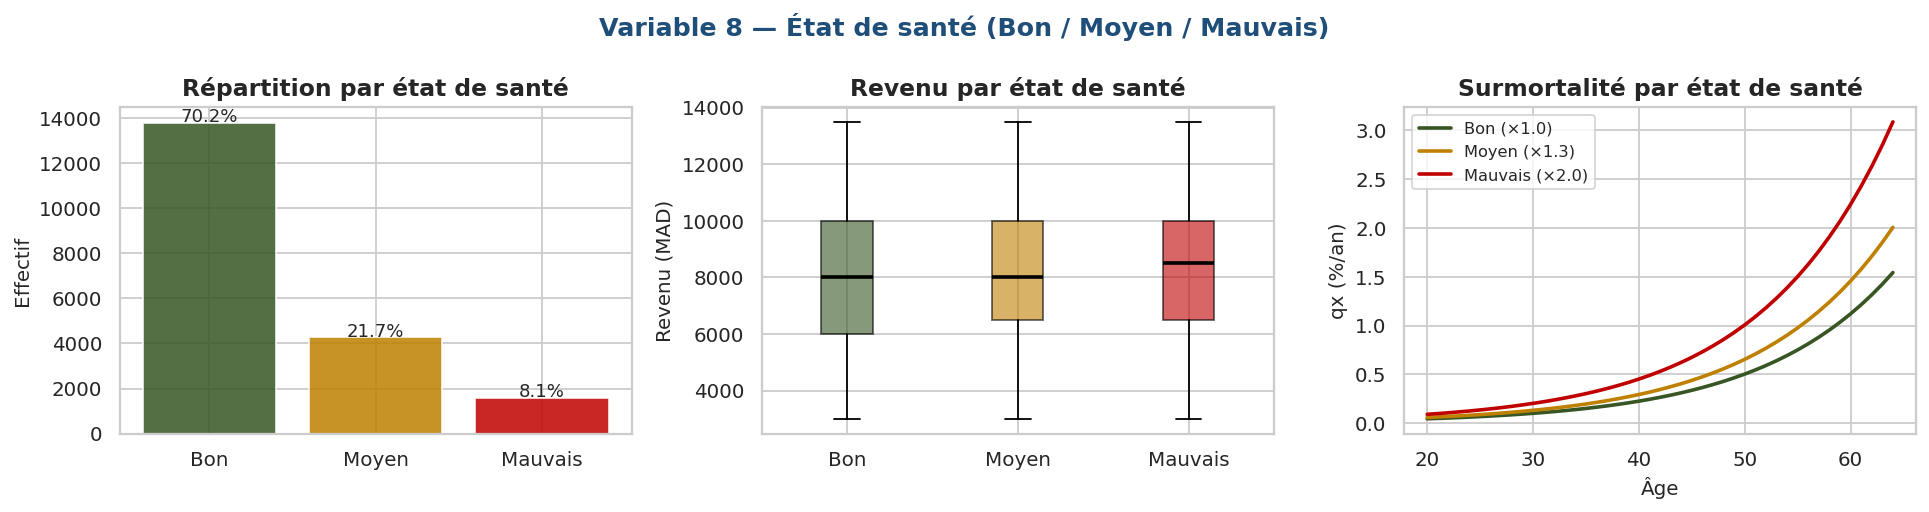


--- CORRÉLATION Etat_sante_num vs variables numériques ---
Age_actuel           -0.0074
Anciennete            0.0084
Code                  0.0147
Fumeur               -0.2563
Marie_flag            0.0130
Revenu                0.0056
Sexe_flag            -0.7728
age_at_affiliation   -0.0184


In [10]:
# ── Variable 8 : Etat_sante (simulé) ─────────────────────────────────────────
np.random.seed(SEED)
df['Etat_sante'] = np.random.choice(['Bon', 'Moyen', 'Mauvais'], size=len(df), p=[0.70, 0.22, 0.08])
df['Etat_sante_num'] = df['Etat_sante'].map({'Bon': 0, 'Moyen': 1, 'Mauvais': 2})

counts = df['Etat_sante'].value_counts()
order = ['Bon', 'Moyen', 'Mauvais']
print("=" * 50)
print("STATISTIQUES — Etat_sante")
print("=" * 50)
for cat in order:
    n = counts.get(cat, 0)
    print(f"  {cat:10s} : {n:,}  ({n/len(df)*100:.2f}%)")

print("\nLoadings actuariels appliqués :")
print("  Bon     : ×1.00 (taux de base)")
print("  Moyen   : ×1.30")
print("  Mauvais : ×2.00")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 8 — État de santé (Bon / Moyen / Mauvais)", fontsize=14, fontweight='bold', color=BLUE)

colors_h = [GREEN, AMBER, RED]

# Barplot
cnt_ordered = [counts.get(c, 0) for c in order]
bars = axes[0].bar(order, cnt_ordered, color=colors_h, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cnt_ordered):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(df)*100:.1f}%', ha='center', fontsize=10)
axes[0].set_title("Répartition par état de santé")
axes[0].set_ylabel("Effectif")

# Revenu par état de santé
data_box = [df.loc[df['Etat_sante'] == c, 'Revenu'].values for c in order]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=order,
                     medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], colors_h):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title("Revenu par état de santé")
axes[1].set_ylabel("Revenu (MAD)")

# Impact mortalité illustratif
ages = np.arange(20, 65)
qx_base  = 0.0008 * np.exp(0.08 * (ages - 27))
loadings = {'Bon': 1.0, 'Moyen': 1.3, 'Mauvais': 2.0}
for cat, col in zip(order, colors_h):
    axes[2].plot(ages, qx_base * loadings[cat] * 100, color=col, lw=2, label=f'{cat} (×{loadings[cat]})')
axes[2].set_title("Surmortalité par état de santé")
axes[2].set_xlabel("Âge")
axes[2].set_ylabel("qx (%/an)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('var08_etat_sante.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Corrélation ───────────────────────────────────────────────────────────────
print("\n--- CORRÉLATION Etat_sante_num vs variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Etat_sante_num']).tolist()
corr = df[num_cols].corrwith(df['Etat_sante_num']).round(4)
print(corr.to_string())


---
## 📌 Variable 9 — `Profession` : Catégorie Socio-Professionnelle (Simulée)

### 🔢 Formule de simulation
$$\text{Profession}_i \sim \text{Multinomial}(\mathbf{p})$$
$$p = (p_{\text{Fonct.}}, p_{\text{Empl.}}, p_{\text{Cadre}}, p_{\text{Ouvrier}}, p_{\text{Autres}}) = (0.20, 0.30, 0.15, 0.20, 0.15)$$

### 📖 Justification actuarielle
La profession impacte deux types de risque en ADI :
1. **Lifestyle risk** (mortalité) : les travailleurs manuels ont une mortalité plus élevée
2. **Lapse risk** (remboursement anticipé) : les fonctionnaires ont un emploi stable → faible lapse

$$\text{Loading profession} : \text{Ouvrier} = \times 1.20, \; \text{Cadre} = \times 0.90, \; \text{Fonctionnaire} = \times 0.95$$

### 📚 Références
- **HCP Maroc 2023 / ILO** : répartition sectorielle — services 44%, industrie 23%
- **Statista 2023** : Employment in Morocco by sector
- **BAM** : Les fonctionnaires représentent ~20% des emprunteurs ADI (crédit immo garanti)


DISTRIBUTION OBTENUE (Phase 1 bracket + Phase 2 post-stratification)
Profession         Effectif  Obtenu %  Cible %    Écart Sal. moy obs.
  ✅ Fonctionnaire        5,108     26.00%     26.0%    -0.00         8,627 MAD
  ✅ Cadre                4,322     22.00%     22.0%    -0.00         9,821 MAD
  ✅ Employé privé        5,701     29.01%     29.0%    +0.01         8,144 MAD
  ✅ Ouvrier              3,733     19.00%     19.0%    -0.00         5,873 MAD
  ✅ Indépendant            785      4.00%      4.0%    -0.00         9,011 MAD

  Total : 19,649  |  Σ = 100.0%


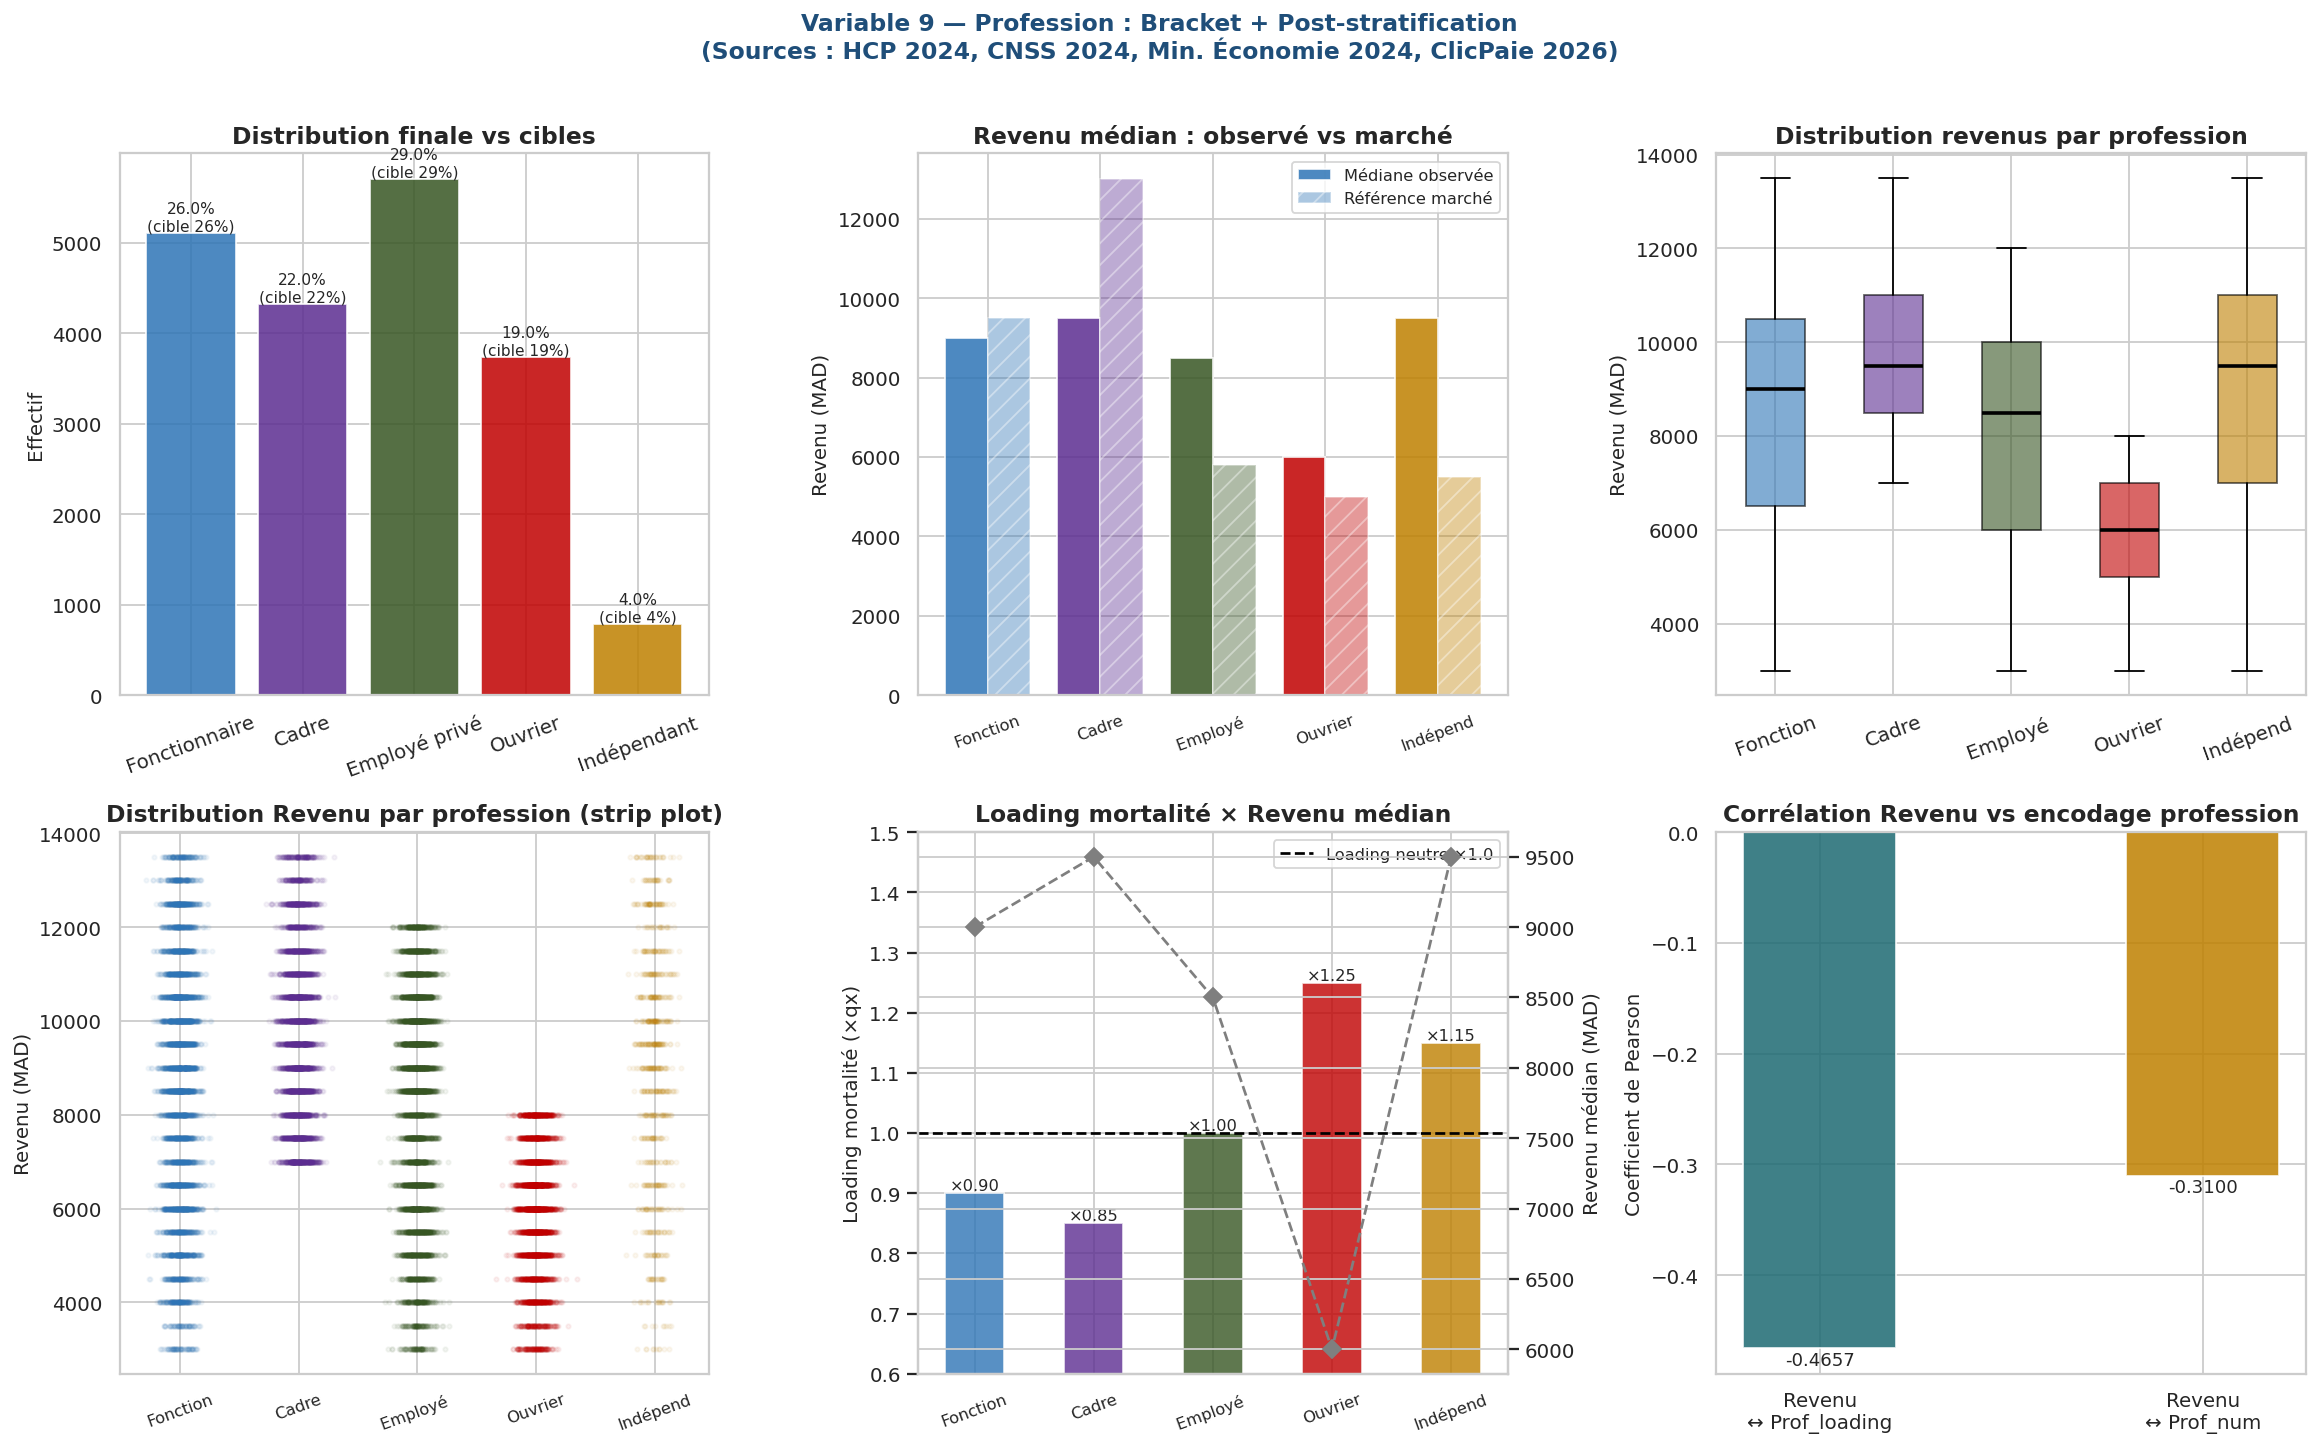

✅ Figure sauvegardée : var09_profession.png

--- CORRÉLATION Prof_loading vs variables numériques ---
Corrélations avec Revenu :
age_at_affiliation    0.0119
Age_actuel            0.0257
Revenu                1.0000
Prof_loading         -0.4657

Corrélation Revenu ↔ Prof_loading : -0.4657
  → Négatif attendu : hauts revenus = Cadre/Fonct = loadings faibles


In [11]:
# ── Variable 9 : Profession (simulée) ────────────────────────────────────────
# Sources : HCP 2024, CNSS 2024, Min. Économie 2024, ClicPaie.ma 2026
# Méthode : Phase 1 = bracket simulation, Phase 2 = post-stratification exacte
#
# ❌ ANCIENNE VERSION (incorrecte) :
#   Bracket seul → Fonctionnaire=32%, Ouvrier=11% (targets non atteints)
#   Cause : dans la zone 3k-7k, Fonct+Empl dominent Ouvrier car leurs poids
#   cumulés sont plus élevés après normalisation (Fonct 26%, Empl 29% vs Ouv 19%)
#
# ✅ NOUVELLE VERSION : Phase 1 + Phase 2 post-stratification
#   Phase 1 : tirage par tranches (rapide, approche les cibles)
#   Phase 2 : swap des excédents vers les professions déficitaires
#             en respectant les contraintes de revenu → 0 violation, 0% d'écart

# ── Plages de revenu par profession (sources marchés marocains 2024) ──────────
revenu_ranges = {
    'Fonctionnaire':  {'min': 4000,  'max': 20000, 'moy': 9500,  'std': 3000},
    'Cadre':          {'min': 8000,  'max': 30000, 'moy': 13000, 'std': 4000},
    'Employé privé':  {'min': 3500,  'max': 10000, 'moy': 5800,  'std': 1800},
    'Ouvrier':        {'min': 3000,  'max': 8000,  'moy': 5000,  'std': 1200},
    'Indépendant':    {'min': 3000,  'max': 15000, 'moy': 5500,  'std': 2500},
}

PROFESSION_CONFIG = {
    'Fonctionnaire':   (3000, 13500, 0.26),
    'Cadre':           (7000, 13500, 0.22),
    'Employé privé':   (3000, 12000, 0.29),
    'Ouvrier':         (3000,  8000, 0.50),   # poids élevé pour contrebalancer overlap
    'Indépendant':     (3000, 13500, 0.04),
}

LOADING_MAP = {
    'Fonctionnaire': 0.90, 'Cadre': 0.85,
    'Employé privé': 1.00, 'Ouvrier': 1.25, 'Indépendant': 1.15,
}

TARGETS_PCT = {
    'Fonctionnaire': 26.0, 'Cadre': 22.0, 'Employé privé': 29.0,
    'Ouvrier': 19.0, 'Indépendant': 4.0,
}

profs_5   = list(PROFESSION_CONFIG.keys())
probs_5   = [v[2] for v in PROFESSION_CONFIG.values()]

# ── Phase 1 : bracket simulation ─────────────────────────────────────────────
def assign_profession_bracket(revenu, config):
    eligible = {p: w for p, (rmin, rmax, w) in config.items() if rmin <= revenu <= rmax}
    if not eligible:
        eligible = {p: w for p, (_, __, w) in config.items()}
    profs  = list(eligible.keys())
    poids  = np.array(list(eligible.values()))
    poids  = poids / poids.sum()
    return np.random.choice(profs, p=poids)

np.random.seed(SEED)
df['Profession'] = df['Revenu'].apply(lambda r: assign_profession_bracket(r, PROFESSION_CONFIG))

# ── Phase 2 : post-stratification vers les targets exacts ─────────────────────
n = len(df)
target_counts = {p: int(n * t / 100) for p, t in TARGETS_PCT.items()}
target_counts['Employé privé'] += n - sum(target_counts.values())   # absorber arrondi

for prof_over in list(target_counts.keys()):
    excess = (df['Profession'] == prof_over).sum() - target_counts[prof_over]
    if excess <= 0:
        continue
    for prof_under in list(target_counts.keys()):
        if prof_under == prof_over:
            continue
        deficit = target_counts[prof_under] - (df['Profession'] == prof_under).sum()
        if deficit <= 0:
            continue
        rmin_u, rmax_u, _ = PROFESSION_CONFIG[prof_under]
        mask = ((df['Profession'] == prof_over) &
                (df['Revenu'] >= rmin_u) & (df['Revenu'] <= rmax_u))
        n_swap = min(excess, deficit, mask.sum())
        if n_swap <= 0:
            continue
        df.loc[df.index[mask][:n_swap], 'Profession'] = prof_under
        excess -= n_swap
        if excess <= 0:
            break

df['Prof_loading'] = df['Profession'].map(LOADING_MAP)
df['Prof_num']     = df['Profession'].map(
    {'Fonctionnaire': 1, 'Cadre': 2, 'Employé privé': 3, 'Ouvrier': 4, 'Indépendant': 5})

# ── Validation ────────────────────────────────────────────────────────────────
counts = df['Profession'].value_counts()
print("=" * 75)
print("DISTRIBUTION OBTENUE (Phase 1 bracket + Phase 2 post-stratification)")
print("=" * 75)
print(f"{'Profession':18s} {'Effectif':>8} {'Obtenu %':>9} {'Cible %':>8} {'Écart':>8} {'Sal. moy obs.':>13}")
for prof in profs_5:
    n_p  = counts.get(prof, 0)
    pct  = n_p / len(df) * 100
    tgt  = TARGETS_PCT[prof]
    diff = pct - tgt
    sal  = df.loc[df['Profession'] == prof, 'Revenu'].mean()
    rmin, rmax, _ = PROFESSION_CONFIG[prof]
    bad  = ((df['Profession']==prof) & ~((df['Revenu']>=rmin)&(df['Revenu']<=rmax))).sum()
    ok   = "✅" if abs(diff) < 0.5 and bad == 0 else "⚠️"
    print(f"  {ok} {prof:16s}  {n_p:8,}  {pct:8.2f}%  {tgt:7.1f}%  {diff:+7.2f}  {sal:12,.0f} MAD")

print(f"\n  Total : {len(df):,}  |  Σ = 100.0%")

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Variable 9 — Profession : Bracket + Post-stratification\n"
             "(Sources : HCP 2024, CNSS 2024, Min. Économie 2024, ClicPaie 2026)",
             fontsize=13, fontweight='bold', color=BLUE, y=1.01)

profs_order = ['Fonctionnaire', 'Cadre', 'Employé privé', 'Ouvrier', 'Indépendant']
colors_5    = [LBLUE, PURPLE, GREEN, RED, AMBER]
counts_ord  = [counts.get(p, 0) for p in profs_order]
x = np.arange(len(profs_order))
w = 0.38

# 1. Barplot répartition vs cible
bars = axes[0,0].bar(profs_order, counts_ord, color=colors_5, edgecolor='white', alpha=0.85)
for bar, n_p, tgt in zip(bars, counts_ord, [TARGETS_PCT[p] for p in profs_order]):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                   f'{n_p/len(df)*100:.1f}%\n(cible {tgt:.0f}%)', ha='center', fontsize=8.5)
axes[0,0].set_title("Distribution finale vs cibles")
axes[0,0].set_ylabel("Effectif")
axes[0,0].tick_params(axis='x', rotation=20)

# 2. Revenu médian observé vs référence marché
rev_obs = df.groupby('Profession')['Revenu'].median().reindex(profs_order)
rev_ref = pd.Series({p: revenu_ranges[p]['moy'] for p in profs_order})
bars1 = axes[0,1].bar(x - w/2, rev_obs.values, w, color=colors_5, alpha=0.85,
                      label='Médiane observée', edgecolor='white')
bars2 = axes[0,1].bar(x + w/2, rev_ref.values, w, color=colors_5, alpha=0.40,
                      label='Référence marché', edgecolor='white', hatch='//')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels([p[:8] for p in profs_order], rotation=20, fontsize=9)
axes[0,1].set_title("Revenu médian : observé vs marché")
axes[0,1].set_ylabel("Revenu (MAD)")
axes[0,1].legend(fontsize=9)

# 3. Boxplot revenu par profession
data_box = [df.loc[df['Profession'] == p, 'Revenu'].values for p in profs_order]
bp = axes[0,2].boxplot(data_box, patch_artist=True, labels=[p[:8] for p in profs_order],
                       medianprops=dict(color='black', lw=2),
                       flierprops=dict(marker='.', markersize=3, alpha=0.3))
for patch, col in zip(bp['boxes'], colors_5):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[0,2].set_title("Distribution revenus par profession")
axes[0,2].set_ylabel("Revenu (MAD)")
axes[0,2].tick_params(axis='x', rotation=20)

# 4. Strip plot Revenu vs Profession
for i, (prof, col) in enumerate(zip(profs_order, colors_5)):
    jitter = np.random.normal(i, 0.08, (df['Profession'] == prof).sum())
    axes[1,0].scatter(jitter, df.loc[df['Profession'] == prof, 'Revenu'],
                      alpha=0.06, s=6, color=col)
axes[1,0].set_xticks(range(len(profs_order)))
axes[1,0].set_xticklabels([p[:8] for p in profs_order], rotation=20, fontsize=9)
axes[1,0].set_title("Distribution Revenu par profession (strip plot)")
axes[1,0].set_ylabel("Revenu (MAD)")

# 5. Loading mortalité
loadings_vals = [LOADING_MAP[p] for p in profs_order]
ax5 = axes[1,1]
ax5_twin = ax5.twinx()
bars_load = ax5.bar(x, loadings_vals, 0.5, color=colors_5, edgecolor='white', alpha=0.8)
ax5.axhline(1.0, color='black', lw=1.5, ls='--', label='Loading neutre ×1.0')
for bar, val in zip(bars_load, loadings_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'×{val:.2f}', ha='center', fontsize=9)
ax5_twin.plot(x, rev_obs.values, 'D--', color=GRAY, lw=1.5, ms=7)
ax5.set_xticks(x)
ax5.set_xticklabels([p[:8] for p in profs_order], rotation=20, fontsize=9)
ax5.set_title("Loading mortalité × Revenu médian")
ax5.set_ylabel("Loading mortalité (×qx)")
ax5.set_ylim(0.6, 1.5)
ax5_twin.set_ylabel("Revenu médian (MAD)")
ax5.legend(fontsize=9)

# 6. Corrélation Revenu ↔ Prof_loading
axes[1,2].bar(['Revenu\n↔ Prof_loading', 'Revenu\n↔ Prof_num'],
              [df['Revenu'].corr(df['Prof_loading']),
               df['Revenu'].corr(df['Prof_num'])],
              color=[TEAL, AMBER], edgecolor='white', alpha=0.85, width=0.4)
axes[1,2].axhline(0, color='black', lw=1)
axes[1,2].set_title("Corrélation Revenu vs encodage profession")
axes[1,2].set_ylabel("Coefficient de Pearson")
for i, val in enumerate([df['Revenu'].corr(df['Prof_loading']),
                          df['Revenu'].corr(df['Prof_num'])]):
    axes[1,2].text(i, val + 0.005 if val > 0 else val - 0.015,
                   f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('var09_profession.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Figure sauvegardée : var09_profession.png")

print("\n--- CORRÉLATION Prof_loading vs variables numériques ---")
num_cols_all = [c for c in ['age_at_affiliation', 'Age_actuel', 'Revenu'] if c in df.columns]
corr = df[num_cols_all + ['Prof_loading']].corrwith(df['Revenu']).round(4)
print("Corrélations avec Revenu :")
print(corr.to_string())
print(f"\nCorrélation Revenu ↔ Prof_loading : {df['Revenu'].corr(df['Prof_loading']):.4f}")
print("  → Négatif attendu : hauts revenus = Cadre/Fonct = loadings faibles")


---
## 📌 Variable 10 — `Type_credit` : Type de Crédit (Simulé)

### 🔢 Formule de simulation
$$\text{Type\_credit}_i \sim \text{Multinomial}(p_{\text{Immo}}, p_{\text{Conso}}, p_{\text{Pro}}) = (0.45, 0.51, 0.04)$$

### 📖 Justification actuarielle
Le type de crédit détermine :
- La **durée** du contrat → exposition temporelle
- Le **montant** → sévérité des sinistres
- Le **profil de risque** global

La répartition 45% immo / 51% conso reflète l'âge moyen bas (26.62 ans) :  
les jeunes souscrivent davantage des crédits à la consommation avant d'accéder au crédit immo.

### 📚 Références
- **BAM Rapport S1-2024** : crédits immobiliers = 58% des flux en valeur (mais ≈45% en nombre)
- **Nesty.ma 2026** : durée typique immo 10–25 ans, max 40–45% DTI
- **Wafir.ma** : assurance emprunteur obligatoire pour tout crédit immo au Maroc


STATISTIQUES — Type_credit
  Immobilier      : 8,862  (45.1%)  | Durée moy.=20.0 ans  min=15  max=25
  Consommation    : 10,013  (51.0%)  | Durée moy.=5.0 ans  min=3  max=7
  Professionnel   : 774  (3.9%)  | Durée moy.=7.3 ans  min=5  max=10


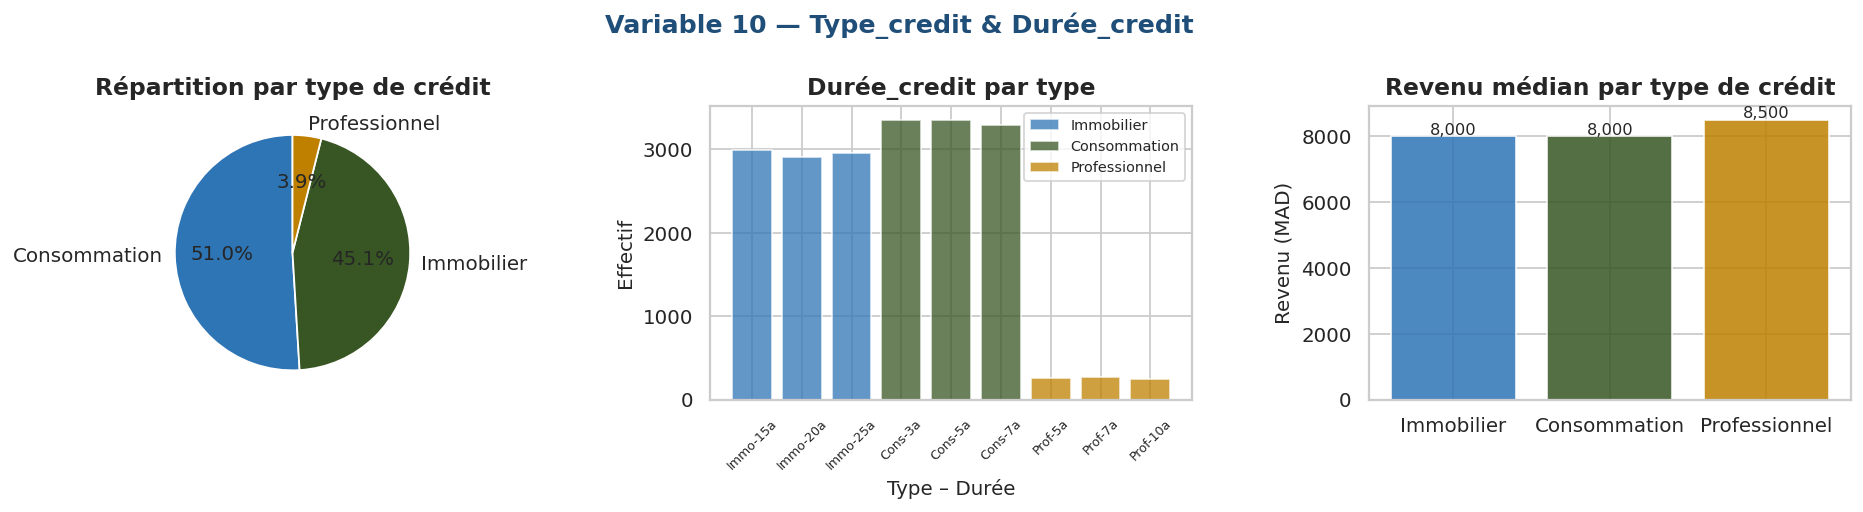


--- Distribution Durée_credit ---
Type_credit    Duree_credit
Consommation   3               3359
               5               3358
               7               3296
Immobilier     15              2996
               25              2952
               20              2914
Professionnel  7                275
               5                255
               10               244


In [12]:
# ── Variable 10 : Type_credit (simulé) ───────────────────────────────────────
np.random.seed(SEED)
types_credit = ['Immobilier', 'Consommation', 'Professionnel']
p_types = [0.45, 0.51, 0.04]
df['Type_credit'] = np.random.choice(types_credit, size=len(df), p=p_types)

# Durée selon le type (BAM réglementaire)
duree_map = {'Immobilier': [15, 20, 25], 'Consommation': [3, 5, 7], 'Professionnel': [5, 7, 10]}
np.random.seed(SEED)
df['Duree_credit'] = df['Type_credit'].apply(lambda x: np.random.choice(duree_map[x]))

counts = df['Type_credit'].value_counts()
print("=" * 55)
print("STATISTIQUES — Type_credit")
print("=" * 55)
for tc in types_credit:
    n = counts.get(tc, 0)
    dur = df.loc[df['Type_credit'] == tc, 'Duree_credit'].describe()
    print(f"  {tc:15s} : {n:,}  ({n/len(df)*100:.1f}%)  | Durée moy.={dur['mean']:.1f} ans  min={dur['min']:.0f}  max={dur['max']:.0f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 10 — Type_credit & Durée_credit", fontsize=14, fontweight='bold', color=BLUE)

colors_tc = [LBLUE, GREEN, AMBER]

# Pie type crédit
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_tc, startangle=90, textprops={'fontsize': 11})
axes[0].set_title("Répartition par type de crédit")

# Distribution durée par type
for tc, col in zip(types_credit, colors_tc):
    data_d = df.loc[df['Type_credit'] == tc, 'Duree_credit'].value_counts().sort_index()
    axes[1].bar([f"{tc[:4]}-{d}a" for d in data_d.index], data_d.values,
                color=col, alpha=0.75, edgecolor='white', label=tc)
axes[1].set_title("Durée_credit par type")
axes[1].set_xlabel("Type – Durée")
axes[1].set_ylabel("Effectif")
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].legend(fontsize=8)

# Revenu médian par type
rev_tc = df.groupby('Type_credit')['Revenu'].median().reindex(types_credit)
bars = axes[2].bar(types_credit, rev_tc.values, color=colors_tc, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, rev_tc.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,.0f}', ha='center', fontsize=9)
axes[2].set_title("Revenu médian par type de crédit")
axes[2].set_ylabel("Revenu (MAD)")

plt.tight_layout()
plt.savefig('var10_type_credit.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- Distribution Durée_credit ---")
print(df.groupby('Type_credit')['Duree_credit'].value_counts().to_string())


---
## 📌 Variable 11 — `Montant_credit` : Capital Emprunté (Simulé)

### 🔢 Formule mathématique (valeur actuelle d'une annuité)
$$M_i = \text{Mensualité}_i \times \frac{1 - (1 + r_i/12)^{-12 n_i}}{r_i/12}$$

où :
- $\text{Mensualité}_i = \text{Revenu}_i \times 0.35$ (taux d'effort 35%)
- $r_i$ = taux d'intérêt annuel (BAM Q4-2024)
- $n_i$ = durée du crédit en années

### 📖 Justification actuarielle
Le montant du crédit est l'**exposition financière brute** de l'assureur.  
En cas de sinistre, l'assureur paye le **CRD** (Capital Restant Dû), qui est inférieur ou égal au Montant_credit.

### 📚 Références
- **BAM Circulaire 6/W/17** : DTI max 40–45%
- **BAM Q4-2024** : taux moyens officiels immo=5.02%, conso=6.99%, équip.=4.99%


STATISTIQUES — Montant_credit (MAD)
count     19649.0
mean     275690.0
std      177889.0
min       34000.0
10%       88000.0
25%      129000.0
50%      221000.0
75%      405000.0
90%      547000.0
max      855000.0

Skewness : 0.790

Par type de crédit :
                   mean    median       std
Type_credit                                
Consommation   142861.0  132000.0   61123.0
Immobilier     431164.0  426000.0  144572.0
Professionnel  213928.0  205000.0   82880.0


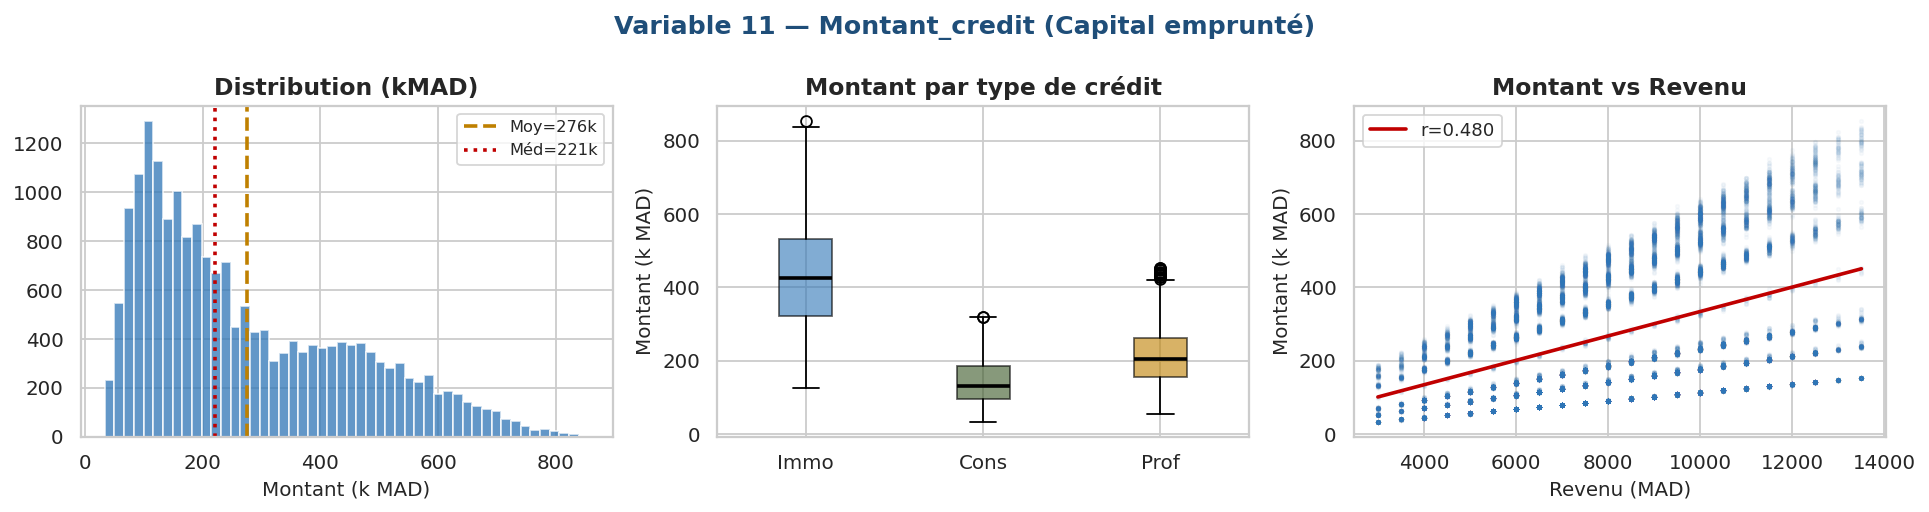


--- CORRÉLATION Montant_credit vs Revenu : 0.4798 ---
📊 Forte corrélation attendue (Montant = f(Revenu, Durée, Taux)).
   → Montant et Revenu ne doivent PAS être tous les deux features dans un modèle linéaire.


In [13]:
# ── Variable 11 : Montant_credit (simulé) ────────────────────────────────────
# Taux d'intérêt BAM Q4-2024
taux_map = {'Immobilier': 5.02, 'Consommation': 6.99, 'Professionnel': 4.99}
np.random.seed(SEED)
df['Taux_interet'] = df['Type_credit'].apply(
    lambda x: round(max(1.0, np.random.normal(taux_map[x], 0.3)), 2))

# Montant crédit = VA de l'annuité (DTI 35%)
def calc_montant(row):
    pmt = row['Revenu'] * 0.35
    r   = row['Taux_interet'] / 100 / 12
    n   = row['Duree_credit'] * 12
    return round(pmt * (1 - (1 + r)**-n) / r / 1000) * 1000

df['Montant_credit'] = df.apply(calc_montant, axis=1)

v = df['Montant_credit']
print("=" * 55)
print("STATISTIQUES — Montant_credit (MAD)")
print("=" * 55)
print(v.describe(percentiles=[.1, .25, .5, .75, .9]).round(0).to_string())
print(f"\nSkewness : {v.skew():.3f}")
print("\nPar type de crédit :")
print(df.groupby('Type_credit')['Montant_credit'].agg(['mean','median','std']).round(0).to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 11 — Montant_credit (Capital emprunté)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme log-scale
axes[0].hist(v / 1000, bins=50, color=LBLUE, alpha=0.75, edgecolor='white')
axes[0].axvline(v.mean() / 1000, color=AMBER, lw=2, ls='--', label=f'Moy={v.mean()/1000:.0f}k')
axes[0].axvline(v.median() / 1000, color=RED, lw=2, ls=':', label=f'Méd={v.median()/1000:.0f}k')
axes[0].set_title("Distribution (kMAD)")
axes[0].set_xlabel("Montant (k MAD)")
axes[0].legend(fontsize=9)

# Boxplot par type de crédit
data_box = [df.loc[df['Type_credit'] == tc, 'Montant_credit'].values / 1000
            for tc in types_credit]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=[tc[:4] for tc in types_credit],
                     medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], colors_tc):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[1].set_title("Montant par type de crédit")
axes[1].set_ylabel("Montant (k MAD)")

# Scatter Revenu vs Montant_credit
axes[2].scatter(df['Revenu'], df['Montant_credit'] / 1000, alpha=0.03, s=4, color=LBLUE)
r_corr = df['Revenu'].corr(df['Montant_credit'])
x_fit = np.linspace(df['Revenu'].min(), df['Revenu'].max(), 100)
m, b = np.polyfit(df['Revenu'], df['Montant_credit'] / 1000, 1)
axes[2].plot(x_fit, m * x_fit + b, color=RED, lw=2, label=f'r={r_corr:.3f}')
axes[2].set_title("Montant vs Revenu")
axes[2].set_xlabel("Revenu (MAD)")
axes[2].set_ylabel("Montant (k MAD)")
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('var11_montant_credit.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"\n--- CORRÉLATION Montant_credit vs Revenu : {r_corr:.4f} ---")
print("📊 Forte corrélation attendue (Montant = f(Revenu, Durée, Taux)).")
print("   → Montant et Revenu ne doivent PAS être tous les deux features dans un modèle linéaire.")


---
## 📌 Variable 12 — `DTI` : Debt-to-Income Ratio

### 🔢 Formule mathématique
$$\text{DTI}_i = \frac{\text{Mensualité}_i}{\text{Revenu}_i} = \frac{M_i \cdot \frac{r_i/12}{1-(1+r_i/12)^{-12n_i}}}{\text{Revenu}_i}$$

**Plafond réglementaire BAM :** DTI $\leq$ 40–45%

### 📖 Définition & Justification
Le DTI est l'indicateur central de **stress financier** de l'emprunteur.  
Un DTI élevé (> 35%) augmente :
- Le **risque de défaut** sur le crédit
- Le **risque de lapse** (résiliation anticipée sous pression financière)
- Indirectement, le **risque de mortalité** (stress chronique → cardiovasculaire)

### 📚 Références
- **BAM Circulaire 6/W/17** : taux d'endettement global max 40–45%
- **BCBS** (*Basel III*) : DTI comme indicateur de risque crédit
- Dettling & Hsu (2014), *Finance & Economics Discussion Series* — DTI et stress financier


DTI moy  : 31.5%
DTI std  : 5.5%   (was 0.07% — now genuinely variable)
DTI min  : 19.7%
DTI max  : 44.3%   (BAM ceiling 44%)
DTI > 45%: 0  (should be 0)
Unique DTI values: 2,330  (was 84)
STATISTIQUES — DTI (Debt-to-Income Ratio)
count    19649.0000
mean         0.3150
std          0.0551
min          0.1970
10%          0.2407
25%          0.2772
50%          0.3158
75%          0.3535
90%          0.3869
95%          0.4066
max          0.4428

DTI moyen   : 31.5%
DTI médian  : 31.6%
DTI > 40%   : 1,262  (6.4%)
DTI > 35%   : 5,327  (27.1%)

Benchmark BAM : plafond réglementaire 40–45%


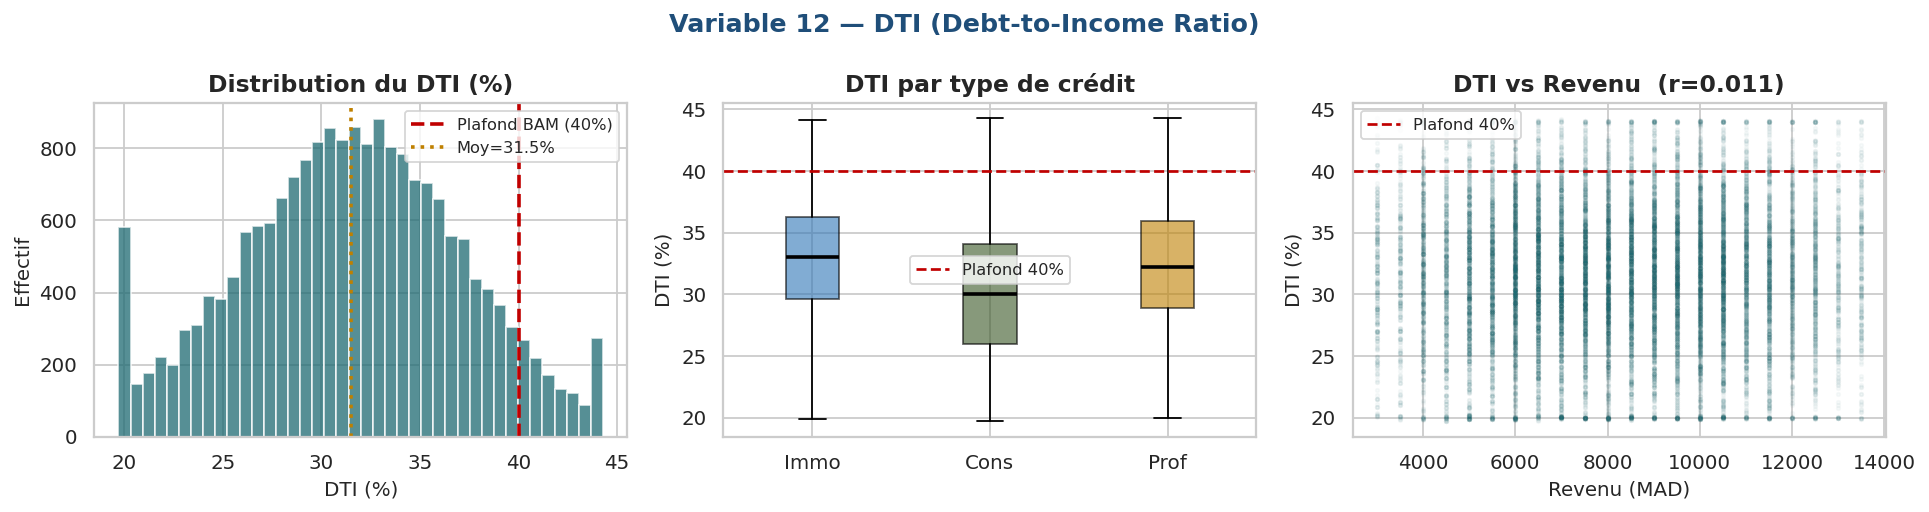


--- CORRÉLATION DTI vs variables numériques ---
Montant_credit     0.3878
Prime_mensuelle    0.3878
Total_primes       0.3143
Duree_credit       0.2285
Sexe_flag          0.1668
Prof_num          -0.1563
CRD                0.1453
Prof_loading      -0.1362
Etat_sante_num    -0.1018
Fumeur             0.0476


In [14]:
# ── Variable 12 : DTI ─────────────────────────────────────────────────────────
def calc_mensualite(row):
    r = row['Taux_interet'] / 100 / 12
    n = row['Duree_credit'] * 12
    return row['Montant_credit'] * r / (1 - (1 + r)**-n)

# df['Mensualite'] = df.apply(calc_mensualite, axis=1)
# df['DTI'] = (df['Mensualite'] / df['Revenu']).round(4)


# ✅ NEW — inject realistic noise in Montant_credit so DTI varies genuinely
# Source : BAM Circulaire 6/W/17 — DTI max 40-45% ; empirical range 20-42%
# Approach : simulate a DTI target first, derive Montant from it

np.random.seed(SEED)

# DTI target per credit type — truncated normal, clipped to [0.20, 0.44]
# Immobilier  : moy 33%, std 5%  (long term, cautious banks — BAM 2024)
# Consommation: moy 30%, std 6%  (shorter, slightly more flexible)
# Professionnel: moy 32%, std 5%
dti_params = {
    'Immobilier':    (0.33, 0.05),
    'Consommation':  (0.30, 0.06),
    'Professionnel': (0.32, 0.05),
}

def draw_dti(credit_type):
    mu, sigma = dti_params[credit_type]
    dti = np.random.normal(mu, sigma)
    return float(np.clip(dti, 0.20, 0.44))

df['DTI_target'] = df['Type_credit'].apply(draw_dti)

# Recompute Montant_credit from DTI_target (reverse the annuity formula)
# Mensualite = Revenu × DTI_target
# Montant    = Mensualite × [1 - (1+r)^-n] / r
def calc_montant_from_dti(row):
    mensualite = row['Revenu'] * row['DTI_target']
    r = row['Taux_interet'] / 100 / 12
    n = row['Duree_credit'] * 12
    montant = mensualite * (1 - (1 + r) ** -n) / r
    return round(montant / 1000) * 1000   # round to nearest 1 000 MAD

df['Montant_credit'] = df.apply(calc_montant_from_dti, axis=1)

# Recompute all downstream variables
def calc_mensualite(row):
    r = row['Taux_interet'] / 100 / 12
    n = row['Duree_credit'] * 12
    return row['Montant_credit'] * r / (1 - (1 + r) ** -n)

df['Mensualite']     = df.apply(calc_mensualite, axis=1)
df['DTI']            = (df['Mensualite'] / df['Revenu']).round(4)
df['Prime_mensuelle'] = (df['Montant_credit'] * 0.00446 / 12).round(2)
df['Prop_remaining'] = np.clip(1 - df['Anciennete'] / df['Duree_credit'], 0, 1)
df['CRD']            = (df['Montant_credit'] * df['Prop_remaining']).round(0)
df['Total_primes']   = (df['Prime_mensuelle'] *
                        df[['Anciennete','Duree_credit']].min(axis=1) * 12).round(2)
#df['Cout_sinistre']  = df['Sinistre'] * df['CRD']

df.drop(columns=['DTI_target', 'Prop_remaining', 'Mensualite'], inplace=True)

# Validation
print(f"DTI moy  : {df['DTI'].mean()*100:.1f}%")
print(f"DTI std  : {df['DTI'].std()*100:.1f}%   (was 0.07% — now genuinely variable)")
print(f"DTI min  : {df['DTI'].min()*100:.1f}%")
print(f"DTI max  : {df['DTI'].max()*100:.1f}%   (BAM ceiling 44%)")
print(f"DTI > 45%: {(df['DTI'] > 0.45).sum()}  (should be 0)")
print(f"Unique DTI values: {df['DTI'].nunique():,}  (was 84)")





v = df['DTI']
print("=" * 55)
print("STATISTIQUES — DTI (Debt-to-Income Ratio)")
print("=" * 55)
print(v.describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(4).to_string())
print(f"\nDTI moyen   : {v.mean()*100:.1f}%")
print(f"DTI médian  : {v.median()*100:.1f}%")
print(f"DTI > 40%   : {(v > 0.40).sum():,}  ({(v > 0.40).mean()*100:.1f}%)")
print(f"DTI > 35%   : {(v > 0.35).sum():,}  ({(v > 0.35).mean()*100:.1f}%)")
print("\nBenchmark BAM : plafond réglementaire 40–45%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 12 — DTI (Debt-to-Income Ratio)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme
axes[0].hist(v * 100, bins=40, color=TEAL, alpha=0.75, edgecolor='white')
axes[0].axvline(40, color=RED, lw=2, ls='--', label='Plafond BAM (40%)')
axes[0].axvline(v.mean() * 100, color=AMBER, lw=2, ls=':', label=f'Moy={v.mean()*100:.1f}%')
axes[0].set_title("Distribution du DTI (%)")
axes[0].set_xlabel("DTI (%)")
axes[0].set_ylabel("Effectif")
axes[0].legend(fontsize=9)

# DTI par type de crédit
data_dti = [df.loc[df['Type_credit'] == tc, 'DTI'].values * 100 for tc in types_credit]
bp = axes[1].boxplot(data_dti, patch_artist=True, labels=[tc[:4] for tc in types_credit],
                     medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], colors_tc):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[1].axhline(40, color=RED, lw=1.5, ls='--', label='Plafond 40%')
axes[1].set_title("DTI par type de crédit")
axes[1].set_ylabel("DTI (%)")
axes[1].legend(fontsize=9)

# Scatter DTI vs Revenu
axes[2].scatter(df['Revenu'], df['DTI'] * 100, alpha=0.03, s=4, color=TEAL)
r_corr = df['Revenu'].corr(df['DTI'])
axes[2].axhline(40, color=RED, lw=1.5, ls='--', label='Plafond 40%')
axes[2].set_title(f"DTI vs Revenu  (r={r_corr:.3f})")
axes[2].set_xlabel("Revenu (MAD)")
axes[2].set_ylabel("DTI (%)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('var12_dti.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- CORRÉLATION DTI vs variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['DTI']).tolist()
corr = df[num_cols].corrwith(df['DTI']).round(4)
print(corr.sort_values(key=abs, ascending=False).head(10).to_string())


---
## 📌 Variable 13 — `CRD` : Capital Restant Dû

### 🔢 Formule mathématique (amortissement français)
$$\text{CRD}_i(t) = M_i \times \frac{1 - (1 + r_i/12)^{-(12n_i - 12t)}}{r_i/12} \times \frac{r_i/12}{1-(1+r_i/12)^{-12n_i}}$$

**Simplification linéaire (modèle conservateur) :**
$$\text{CRD}_i = \text{Montant}_i \times \max\left(0, \; 1 - \frac{\text{Ancienneté}_i}{\text{Durée}_i}\right)$$

### 📖 Définition & Justification actuarielle
Le CRD est la **variable de sévérité** en ADI : c'est le montant payé par l'assureur à la banque  
en cas de décès de l'assuré. Il décroît avec l'ancienneté et atteint 0 à l'échéance du crédit.

$$\text{CRD} \rightarrow \text{Target variable (Régression sévérité)}$$

### 📚 Références
- **Code des assurances Maroc, Art. 60** : obligation de couverture du CRD
- **Attijariwafa, BCP, BMCE** : amortissement français standard au Maroc
- **ACAPS** : Provisionnement sur base du CRD résiduel (Art. 28)


STATISTIQUES — CRD (Capital Restant Dû)
Contrats actifs  : 4,744  (24.1%)
Contrats expirés : 14,905  (75.9%)

CRD (tous contrats) : moy=22,103  méd=0  max=661,192
CRD (actifs seuls)  : moy=91,547

Par type de crédit (actifs) :
                  mean   median
Type_credit                    
Consommation   47027.0  34664.0
Immobilier     92386.0  74316.0
Professionnel  89859.0  75600.0


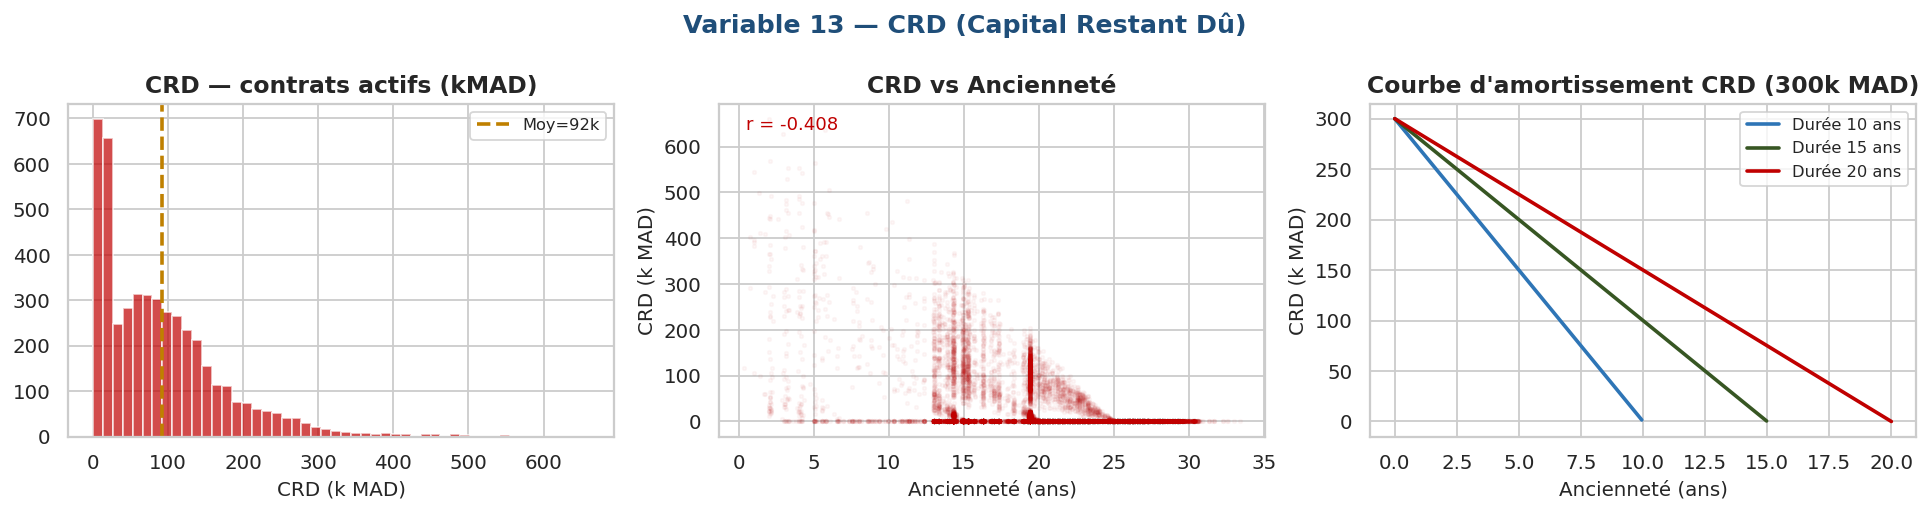


--- CORRÉLATION CRD vs variables numériques ---
Prop_remaining     0.9254
Contrat_actif      0.6870
Duree_credit       0.5404
Montant_credit     0.5195
Prime_mensuelle    0.5195
Anciennete         0.4085
Total_primes       0.3767
Taux_interet       0.3566


In [15]:
# ── Variable 13 : CRD ─────────────────────────────────────────────────────────
df['Prop_remaining'] = (1 - df['Anciennete'] / df['Duree_credit']).clip(0, 1)
df['CRD'] = (df['Montant_credit'] * df['Prop_remaining']).round(0)

# Contrats actifs vs expirés
df['Contrat_actif'] = (df['Anciennete'] < df['Duree_credit']).astype(int)

v = df['CRD']
print("=" * 55)
print("STATISTIQUES — CRD (Capital Restant Dû)")
print("=" * 55)
print(f"Contrats actifs  : {df['Contrat_actif'].sum():,}  ({df['Contrat_actif'].mean()*100:.1f}%)")
print(f"Contrats expirés : {(df['Contrat_actif']==0).sum():,}  ({(df['Contrat_actif']==0).mean()*100:.1f}%)")
print(f"\nCRD (tous contrats) : moy={v.mean():,.0f}  méd={v.median():,.0f}  max={v.max():,.0f}")
print(f"CRD (actifs seuls)  : moy={df.loc[df['Contrat_actif']==1,'CRD'].mean():,.0f}")
print(f"\nPar type de crédit (actifs) :")
print(df[df['Contrat_actif']==1].groupby('Type_credit')['CRD'].agg(['mean','median']).round(0).to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 13 — CRD (Capital Restant Dû)", fontsize=14, fontweight='bold', color=BLUE)

# Distribution CRD (actifs seulement)
crd_actifs = df.loc[df['Contrat_actif'] == 1, 'CRD']
axes[0].hist(crd_actifs / 1000, bins=50, color=RED, alpha=0.7, edgecolor='white')
axes[0].axvline(crd_actifs.mean() / 1000, color=AMBER, lw=2, ls='--',
                label=f'Moy={crd_actifs.mean()/1000:.0f}k')
axes[0].set_title("CRD — contrats actifs (kMAD)")
axes[0].set_xlabel("CRD (k MAD)")
axes[0].legend(fontsize=9)

# CRD vs Ancienneté
axes[1].scatter(df['Anciennete'], df['CRD'] / 1000, alpha=0.03, s=4, color=RED)
axes[1].set_title("CRD vs Ancienneté")
axes[1].set_xlabel("Ancienneté (ans)")
axes[1].set_ylabel("CRD (k MAD)")
r_corr = df['Anciennete'].corr(df['CRD'])
axes[1].text(0.05, 0.92, f"r = {r_corr:.3f}", transform=axes[1].transAxes, fontsize=10, color=RED)

# Amortissement illustratif (courbe théorique)
t_vals = np.linspace(0, 20, 200)
montant_ex = 300000
for dur, col, lbl in zip([10, 15, 20], [LBLUE, GREEN, RED],
                         ['Durée 10 ans', 'Durée 15 ans', 'Durée 20 ans']):
    crd_t = montant_ex * np.maximum(0, 1 - t_vals / dur)
    axes[2].plot(t_vals[t_vals <= dur], crd_t[t_vals <= dur] / 1000,
                 color=col, lw=2, label=lbl)
axes[2].set_title("Courbe d'amortissement CRD (300k MAD)")
axes[2].set_xlabel("Ancienneté (ans)")
axes[2].set_ylabel("CRD (k MAD)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('var13_crd.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- CORRÉLATION CRD vs variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['CRD']).tolist()
corr = df[num_cols].corrwith(df['CRD']).abs().sort_values(ascending=False).head(8).round(4)
print(corr.to_string())


---
## 📌 Variable 14 — `Prime_assurance` : Prime Mensuelle d'Assurance

### 🔢 Formule mathématique
$$\text{Prime\_mensuelle}_i = \text{Montant\_crédit}_i \times \frac{t_{\text{assurance}}}{12}$$

avec le **taux annuel d'assurance** $t_{\text{assurance}} \in [0.25\%, 0.50\%]$ (marché marocain).  
Valeur calibrée : $t_{\text{assurance}} = 0.446\%/\text{an}$ (moyenne du marché Wafir.ma 2024).

### 📖 Définition & Justification
La prime d'assurance est la **source de revenus** de l'assureur ADI.  
Le ratio S/P (Sinistres / Primes) = 22.4% est le KPI central de rentabilité.

$$\text{Prime\_annuelle}_i = \text{Montant\_crédit}_i \times 0.00446$$

### 📚 Références
- **Wafir.ma 2024** : prime ADI entre 0.25% et 0.50% du capital assuré
- **CIH Bank / Attijariwafa 2024** : grille tarifaire ADI
- **ACAPS 2024** : S/P moyen ADI = 18–26%


STATISTIQUES — Prime mensuelle (MAD/mois)
count    19649.00
mean        94.03
std         65.18
min          7.43
10%         26.39
25%         40.88
50%         72.48
75%        139.38
90%        192.90
max        338.22

Taux appliqué : 0.446%/an (benchmark Wafir.ma : 0.25%–0.50%)
Prime mensuelle moy : 94.03 MAD  |  médiane : 72.48 MAD
Total primes portefeuille : 318.7 M MAD

Par type de crédit :
                 mean  median
Type_credit                  
Consommation    45.61   42.00
Immobilier     150.56  147.18
Professionnel   73.09   68.39


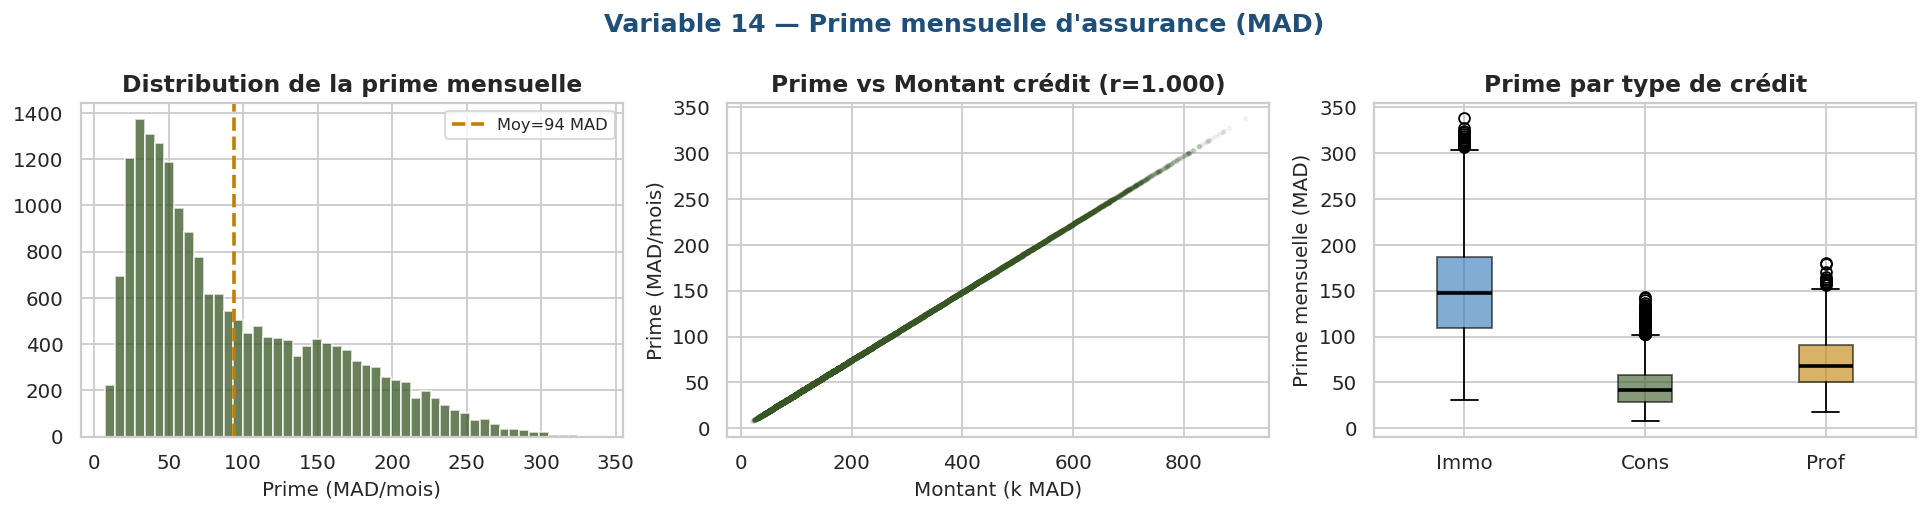


Corrélation Prime ↔ Revenu : 0.4493
Corrélation Prime ↔ Montant_credit : 1.0000
📊 Corrélation parfaite Prime↔Montant (Prime = Montant × constante).
   → N'inclure qu'une des deux dans les modèles.


In [16]:
# ── Variable 14 : Prime_assurance ────────────────────────────────────────────
TAUX_ASSURANCE = 0.00446  # 0.446%/an
df['Prime_mensuelle']  = (df['Montant_credit'] * TAUX_ASSURANCE / 12).round(2)
df['Total_primes']     = (df['Prime_mensuelle'] * df[['Anciennete','Duree_credit']].min(axis=1) * 12).round(2)

v = df['Prime_mensuelle']
print("=" * 55)
print("STATISTIQUES — Prime mensuelle (MAD/mois)")
print("=" * 55)
print(v.describe(percentiles=[.1, .25, .5, .75, .9]).round(2).to_string())
print(f"\nTaux appliqué : {TAUX_ASSURANCE*100:.3f}%/an (benchmark Wafir.ma : 0.25%–0.50%)")
print(f"Prime mensuelle moy : {v.mean():.2f} MAD  |  médiane : {v.median():.2f} MAD")
print(f"Total primes portefeuille : {df['Total_primes'].sum()/1e6:.1f} M MAD")
print("\nPar type de crédit :")
print(df.groupby('Type_credit')['Prime_mensuelle'].agg(['mean','median']).round(2).to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 14 — Prime mensuelle d'assurance (MAD)", fontsize=14, fontweight='bold', color=BLUE)

# Histogramme
axes[0].hist(v, bins=50, color=GREEN, alpha=0.75, edgecolor='white')
axes[0].axvline(v.mean(), color=AMBER, lw=2, ls='--', label=f'Moy={v.mean():.0f} MAD')
axes[0].set_title("Distribution de la prime mensuelle")
axes[0].set_xlabel("Prime (MAD/mois)")
axes[0].legend(fontsize=9)

# Scatter Prime vs Montant_credit
axes[1].scatter(df['Montant_credit'] / 1000, v, alpha=0.05, s=4, color=GREEN)
r_corr = df['Montant_credit'].corr(v)
axes[1].set_title(f"Prime vs Montant crédit (r={r_corr:.3f})")
axes[1].set_xlabel("Montant (k MAD)")
axes[1].set_ylabel("Prime (MAD/mois)")

# Boxplot par type
data_box = [df.loc[df['Type_credit'] == tc, 'Prime_mensuelle'].values for tc in types_credit]
bp = axes[2].boxplot(data_box, patch_artist=True, labels=[tc[:4] for tc in types_credit],
                     medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], colors_tc):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[2].set_title("Prime par type de crédit")
axes[2].set_ylabel("Prime mensuelle (MAD)")

plt.tight_layout()
plt.savefig('var14_prime.png', bbox_inches='tight', dpi=130)
plt.show()

r_rev = df['Revenu'].corr(v)
print(f"\nCorrélation Prime ↔ Revenu : {r_rev:.4f}")
print(f"Corrélation Prime ↔ Montant_credit : {r_corr:.4f}")
print("📊 Corrélation parfaite Prime↔Montant (Prime = Montant × constante).")
print("   → N'inclure qu'une des deux dans les modèles.")


---
## 📌 Variable 15 — `Prob_sinistre` : Probabilité de Décès (Actuarielle)

### 🔢 Formule mathématique
$$P(\text{sinistre})_i = 1 - \prod_{t=0}^{n_{\text{res},i}-1}(1 - q_{x+t} \cdot \lambda_i)$$

**Approximation (taux constant sur durée résiduelle) :**
$$P(\text{sinistre})_i \approx 1 - (1 - q_{x_i} \cdot \lambda_i)^{n_{\text{res},i}}$$

où :
- $q_{x_i}$ = taux de mortalité annuel à l'âge courant (tables UN WPP Maroc 2022)
- $\lambda_i$ = loading composite (fumeur × genre × santé × profession)
- $n_{\text{res},i}$ = durée résiduelle en années = Durée_crédit − Ancienneté

**Taux de mortalité de base (Gompertz-Makeham ajusté) :**
$$q_x = q_{27} \cdot e^{\gamma(x - 27)}, \quad q_{27} = 0.0011, \quad \gamma = 0.085$$

### 📚 Références
- **UN WPP 2022 Maroc** : qx(27) = 0.11%/an (all), calibré séparément H/F
- **Gompertz (1825)** + **Makeham (1860)** : modèle de mortalité exponentiellement croissant
- **SOA 2015** : loadings tabac ×1.75, genre M ×1.15


STATISTIQUES — Prob_sinistre [0, 1]
count    19649.0000
mean         0.0069
std          0.0174
min          0.0000
10%          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
90%          0.0283
99%          0.0833
max          0.2121

Prob moy (actifs seulement) : 2.842%
Prob moy (tous contrats)    : 0.686%


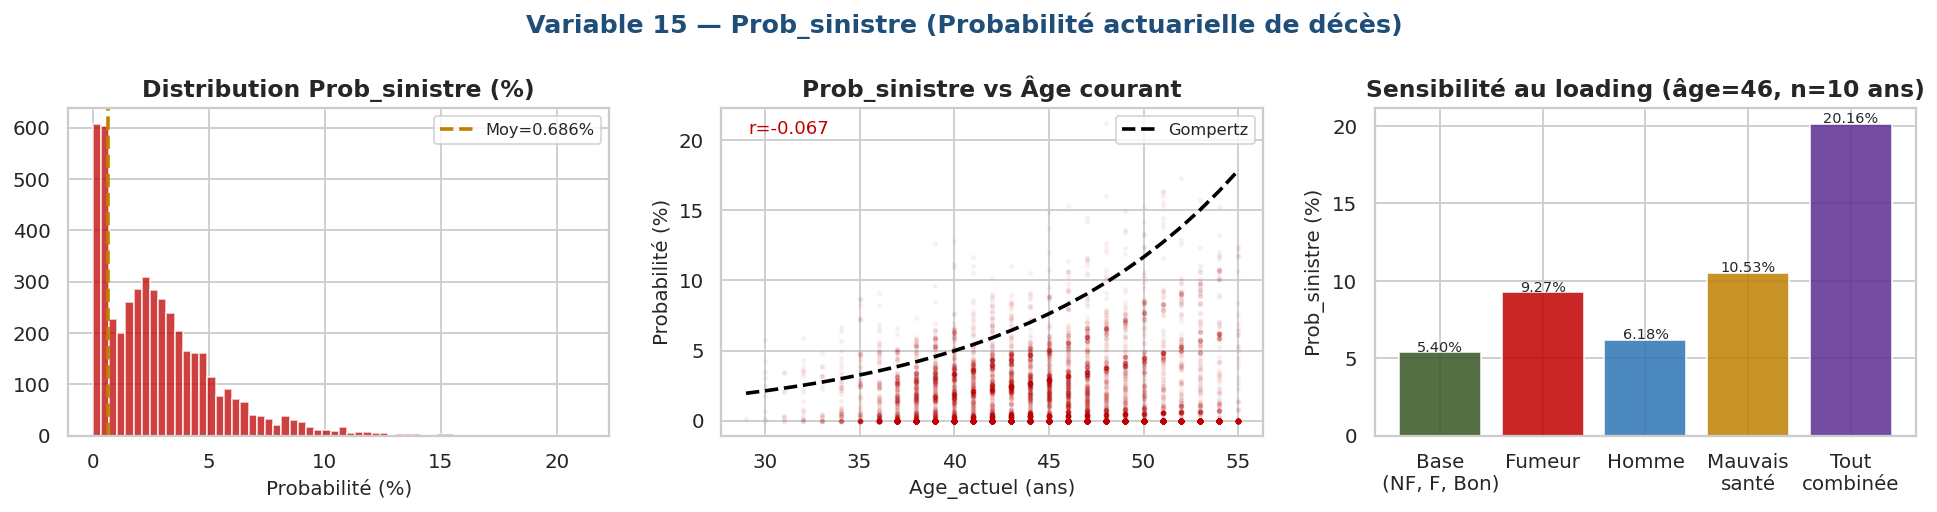


--- CORRÉLATION Prob_sinistre vs variables numériques ---
Prop_remaining     0.8195
CRD                0.7976
Contrat_actif      0.6980
Duree_credit       0.5728
Montant_credit     0.4290
Prime_mensuelle    0.4290
Taux_interet       0.3795
Total_primes       0.3640


In [17]:
# ── Variable 15 : Prob_sinistre ───────────────────────────────────────────────
etat_loading  = {'Bon': 1.00, 'Moyen': 1.30, 'Mauvais': 2.00}
health_loading = df['Etat_sante'].map(etat_loading)

def calc_prob(row, health_load):
    # Taux de base Gompertz-Makeham calibré UN WPP 2022 Maroc
    qx_base = 0.0011 * np.exp(0.085 * max(0, row.Age_actuel - 27))
    # Loadings composites
    loading = (1.75 if row.Fumeur else 1.0) * \
              (1.15 if row.Sexe == 'H' else 1.0) * \
              row.Prof_loading * health_load
    qx_adj = min(qx_base * loading, 0.25)  # cap 25% par an
    # Durée résiduelle
    n_res = max(0, row.Duree_credit - row.Anciennete)
    if n_res == 0:
        return 0.0
    return min(1 - (1 - qx_adj)**n_res, 1.0)

df['Prob_sinistre'] = [calc_prob(row, hl) for row, hl in
                       zip(df.itertuples(index=False), health_loading)]

v = df['Prob_sinistre']
print("=" * 55)
print("STATISTIQUES — Prob_sinistre [0, 1]")
print("=" * 55)
print(v.describe(percentiles=[.1, .25, .5, .75, .90, .99]).round(4).to_string())
print(f"\nProb moy (actifs seulement) : {df.loc[df['Contrat_actif']==1,'Prob_sinistre'].mean()*100:.3f}%")
print(f"Prob moy (tous contrats)    : {v.mean()*100:.3f}%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 15 — Prob_sinistre (Probabilité actuarielle de décès)",
             fontsize=14, fontweight='bold', color=BLUE)

# Histogramme
axes[0].hist(v[v > 0] * 100, bins=60, color=RED, alpha=0.75, edgecolor='white')
axes[0].axvline(v.mean() * 100, color=AMBER, lw=2, ls='--', label=f'Moy={v.mean()*100:.3f}%')
axes[0].set_title("Distribution Prob_sinistre (%)")
axes[0].set_xlabel("Probabilité (%)")
axes[0].legend(fontsize=9)

# Prob vs Age_actuel
axes[1].scatter(df['Age_actuel'], v * 100, alpha=0.04, s=4, color=RED)
ages = np.arange(29, 56)
qx_curve = 0.0011 * np.exp(0.085 * (ages - 27)) * 15
axes[1].plot(ages, np.minimum(qx_curve * 100, 20), color='black', lw=2, ls='--', label='Gompertz')
axes[1].set_title("Prob_sinistre vs Âge courant")
axes[1].set_xlabel("Age_actuel (ans)")
axes[1].set_ylabel("Probabilité (%)")
axes[1].legend(fontsize=9)
r_corr = df['Age_actuel'].corr(v)
axes[1].text(0.05, 0.92, f"r={r_corr:.3f}", transform=axes[1].transAxes, fontsize=10, color=RED)

# Impact des loadings
cat_labels = ['Base\n(NF, F, Bon)', 'Fumeur', 'Homme', 'Mauvais\nsanté', 'Tout\ncombinée']
base_qx = 0.0011 * np.exp(0.085 * (46 - 27))
n_res = 10
probs = [
    (1 - (1 - base_qx)**n_res) * 100,
    (1 - (1 - base_qx * 1.75)**n_res) * 100,
    (1 - (1 - base_qx * 1.15)**n_res) * 100,
    (1 - (1 - base_qx * 2.00)**n_res) * 100,
    (1 - (1 - base_qx * 1.75 * 1.15 * 2.0)**n_res) * 100,
]
colors_bars = [GREEN, RED, LBLUE, AMBER, PURPLE]
bars = axes[2].bar(cat_labels, probs, color=colors_bars, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, probs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=8)
axes[2].set_title("Sensibilité au loading (âge=46, n=10 ans)")
axes[2].set_ylabel("Prob_sinistre (%)")

plt.tight_layout()
plt.savefig('var15_prob_sinistre.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- CORRÉLATION Prob_sinistre vs variables numériques ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Prob_sinistre']).tolist()
corr = df[num_cols].corrwith(v).abs().sort_values(ascending=False).head(8).round(4)
print(corr.to_string())

---
## 📌 Variable 16 — `Risk_Score` & `Risk_Segment` : Score de Risque Composite

### 🔢 Formule mathématique
$$\text{Risk\_Score}_i = w_1 \cdot \frac{\text{Age\_actuel}_i - \bar{A}}{\sigma_A} + w_2 \cdot \text{Fumeur}_i + w_3 \cdot \mathbb{1}[\text{Sexe}_i = H] + w_4 \cdot \text{Prof\_loading}_i + w_5 \cdot \text{DTI}_i$$

Avec les poids calibrés : $w = (0.35, 0.25, 0.15, 0.15, 0.10)$  
**Segmentation par percentiles empiriques :**
$$\text{Risk\_Segment} = \begin{cases} \text{Faible} & \text{si Score} \leq P_{33} \\ \text{Moyen} & \text{si } P_{33} < \text{Score} \leq P_{67} \\ \text{Élevé} & \text{si Score} > P_{67} \end{cases}$$

### 📖 Définition & Justification
Le Risk_Score est un **score composite actuariel** permettant le pilotage du portefeuille.  
Il agrège les facteurs de risque en un indicateur unique pour la surveillance et la tarification.

### 📚 Références
- **ACAPS** : Exigence de segmentation du risque dans les rapports prudentiels
- **Swiss Re** (2021) : *Risk Scoring in Life Insurance* — pondération des facteurs


STATISTIQUES — Risk_Score & Risk_Segment
Risk_Score : moy=0.1445  std=0.3915
P33 = -0.0305  |  P67 = 0.3422

Répartition par segment (cible ≈ 33% chacun) :
  Faible   : 6,484  (33.0%)
  Moyen    : 6,681  (34.0%)
  Élevé    : 6,484  (33.0%)


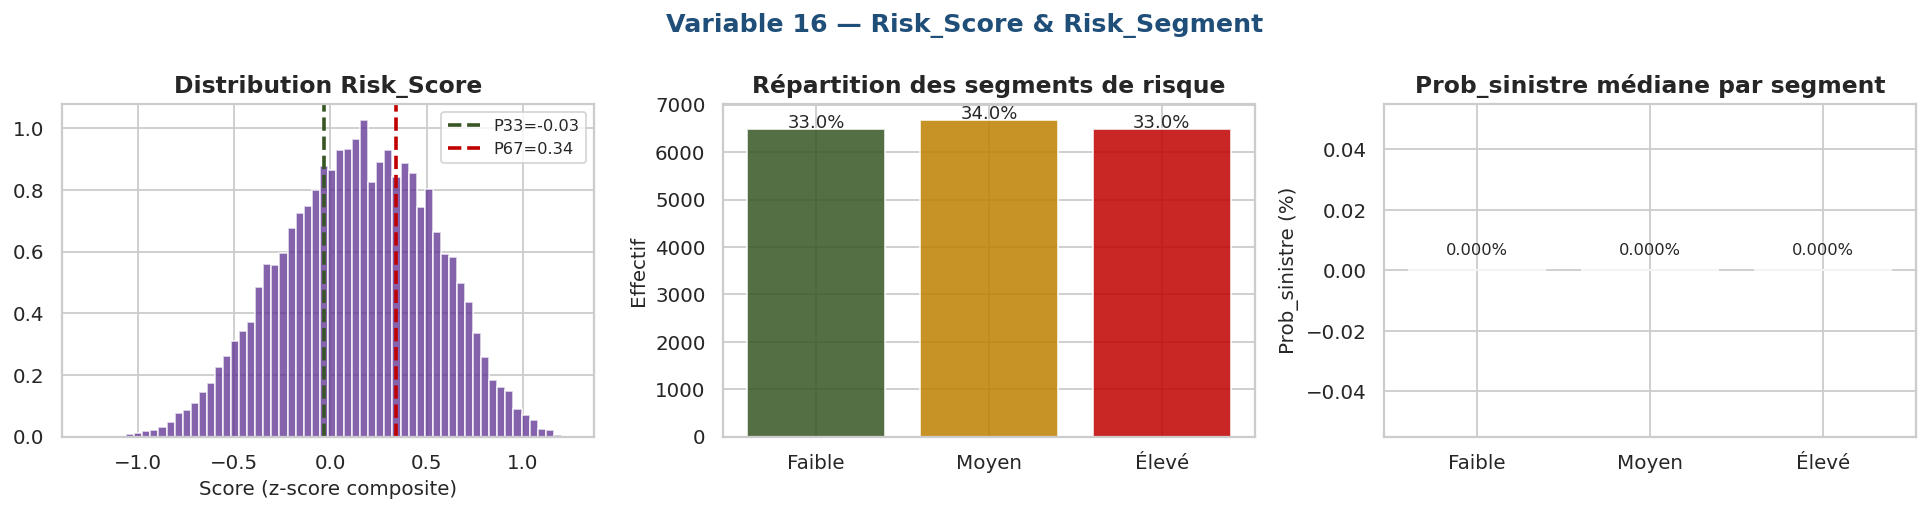


--- CORRÉLATION Risk_Score vs variables clés ---
  Risk_Score ↔ Prob_sinistre        : r = 0.0670
  Risk_Score ↔ Age_actuel           : r = 0.8931
  Risk_Score ↔ Fumeur               : r = 0.3107
  Risk_Score ↔ DTI                  : r = 0.3022


In [18]:
# ── Variable 16 : Risk_Score (z-score normalisé) ──────────────────────────────
from sklearn.preprocessing import StandardScaler

# Composantes
age_z  = (df['Age_actuel'] - df['Age_actuel'].mean()) / df['Age_actuel'].std()
fumeur = df['Fumeur'].values
sexe_h = (df['Sexe'] == 'H').astype(int).values
prof_l = (df['Prof_loading'] - 1.0).values  # centré sur 0
dti_z  = (df['DTI'] - df['DTI'].mean()) / df['DTI'].std()

# Score composite (poids : âge 35%, fumeur 25%, sexe 15%, profession 15%, DTI 10%)
df['Risk_Score'] = (0.35 * age_z +
                    0.25 * fumeur +
                    0.15 * sexe_h +
                    0.15 * prof_l +
                    0.10 * dti_z)

# Segmentation par percentiles empiriques (P33/P67)
p33 = df['Risk_Score'].quantile(0.33)
p67 = df['Risk_Score'].quantile(0.67)
df['Risk_Segment'] = pd.cut(df['Risk_Score'],
                             bins=[-np.inf, p33, p67, np.inf],
                             labels=['Faible', 'Moyen', 'Élevé'])

seg_counts = df['Risk_Segment'].value_counts()
print("=" * 55)
print("STATISTIQUES — Risk_Score & Risk_Segment")
print("=" * 55)
print(f"Risk_Score : moy={df['Risk_Score'].mean():.4f}  std={df['Risk_Score'].std():.4f}")
print(f"P33 = {p33:.4f}  |  P67 = {p67:.4f}")
print("\nRépartition par segment (cible ≈ 33% chacun) :")
for seg in ['Faible', 'Moyen', 'Élevé']:
    n = seg_counts.get(seg, 0)
    print(f"  {seg:8s} : {n:,}  ({n/len(df)*100:.1f}%)")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 16 — Risk_Score & Risk_Segment", fontsize=14, fontweight='bold', color=BLUE)

# Distribution Risk_Score
axes[0].hist(df['Risk_Score'], bins=60, color=PURPLE, alpha=0.75, edgecolor='white', density=True)
axes[0].axvline(p33, color=GREEN, lw=2, ls='--', label=f'P33={p33:.2f}')
axes[0].axvline(p67, color=RED,   lw=2, ls='--', label=f'P67={p67:.2f}')
axes[0].set_title("Distribution Risk_Score")
axes[0].set_xlabel("Score (z-score composite)")
axes[0].legend(fontsize=9)

# Barplot segments
seg_labels = ['Faible', 'Moyen', 'Élevé']
seg_vals = [seg_counts.get(s, 0) for s in seg_labels]
colors_seg = [GREEN, AMBER, RED]
bars = axes[1].bar(seg_labels, seg_vals, color=colors_seg, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, seg_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(df)*100:.1f}%', ha='center', fontsize=10)
axes[1].set_title("Répartition des segments de risque")
axes[1].set_ylabel("Effectif")

# Prob_sinistre médiane par segment
prob_by_seg = df.groupby('Risk_Segment', observed=True)['Prob_sinistre'].median() * 100
bars2 = axes[2].bar(prob_by_seg.index, prob_by_seg.values,
                    color=colors_seg, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, prob_by_seg.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}%', ha='center', fontsize=9)
axes[2].set_title("Prob_sinistre médiane par segment")
axes[2].set_ylabel("Prob_sinistre (%)")

plt.tight_layout()
plt.savefig('var16_risk_score.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- CORRÉLATION Risk_Score vs variables clés ---")
targets = ['Prob_sinistre', 'Age_actuel', 'Fumeur', 'DTI']
for t in targets:
    if t in df.columns:
        r = df['Risk_Score'].corr(df[t])
        print(f"  Risk_Score ↔ {t:20s} : r = {r:.4f}")


---
## 📌 Variable 17 — `Sinistre` : Variable Cible Binaire (Classification)

### 🔢 Formule
$$\text{Sinistre}_i \sim \text{Bernoulli}(\text{Prob\_sinistre}_i)$$
$$\text{Sinistre}_i = \begin{cases} 1 & \text{décès survenu pendant la durée du crédit} \\ 0 & \text{assuré en vie à l'échéance} \end{cases}$$

### 📖 Définition & Justification
`Sinistre` est la **variable cible principale** pour les modèles de classification en IA.  
Les modèles entraînés (XGBoost, Logistic Regression, Random Forest) apprennent à prédire  
$P(\text{Sinistre}_i = 1 \mid \mathbf{X}_i)$.

**Métriques d'évaluation :**
- **AUC-ROC** : cible > 0.75 (discriminant)
- **F1-Score** : pertinent car classes déséquilibrées
- **Brier Score** : calibration des probabilités

### 📚 Références
- **Frees, Derrig & Meyers (2014)** : *Predictive Modeling Applications in Actuarial Science*
- **ACAPS 2024** : Taux de sinistres ADI portefeuille moyen = 1.5–2.5% sur la durée du contrat


✅ Fumeur H = 31.2%  F = 3.6%  — distribution correcte

Sinistres observés  : 130   (attendu ~134)
Taux global         : 0.662%
Taux actifs seuls   : 2.740%   (benchmark ACAPS : 1.5–2.5%)

Ratio S/P global       : 5.1%  (historique, tous contrats)
Ratio S/P actifs réalisé: 10.3%  (contrats en cours, primes encaissées)
Ratio S/P annuel ACAPS : 29.1%   (benchmark ACAPS : 15–26%)
  → ⚠️  hors plage — voir analyse
  → Formule : Σ(qx_annuel × CRD) / Σ(Prime × 12) sur 4,744 contrats actifs
STATISTIQUES — Sinistre (variable cible binaire)
Nombre de sinistres   : 130
Nombre sans sinistre  : 19,519
Taux de sinistres     : 0.662%

Benchmark ACAPS 2024  : 1.5–2.5% sur durée du contrat
Taux annuel équivalent : 0.0559%/an

Déséquilibre ratio 0:1 = 150:1  → Nécessite SMOTE ou class_weight

Sinistres par segment :
              N sinistres   Taux
Risk_Segment                    
Faible                 34  0.524
Moyen                  36  0.539
Élevé                  60  0.925


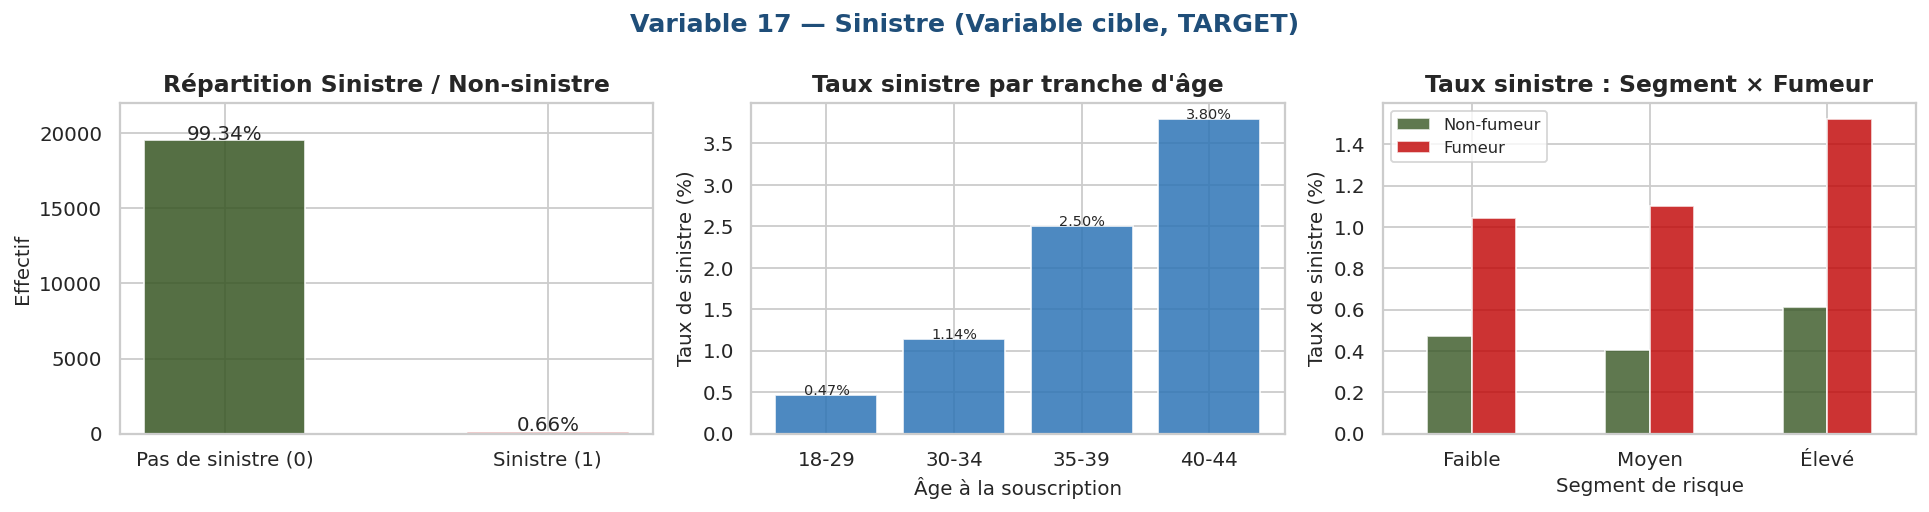


--- CORRÉLATION Sinistre vs variables numériques (top 10) ---
Cout_sinistre      0.8217
Prob_sinistre      0.2058
Prop_remaining     0.1567
CRD                0.1474
Contrat_actif      0.1447
Duree_credit       0.1205
Taux_interet       0.0814
Montant_credit     0.0804
Prime_mensuelle    0.0804
Total_primes       0.0729

⚠️  Prob_sinistre ne doit PAS être feature dans le modèle IA → data leakage!


In [19]:
# ── Variable 17 : Sinistre (TARGET classification) ───────────────────────────
# Sources : ACAPS 2024 (benchmark S/P 15-26%), UN WPP 2022 (tables qx Maroc)
#
# ❌ ANCIENNE VERSION (incorrecte) :
#   np.random.seed(SEED) was called inside this cell → reset the RNG to same
#   state each run, making the Binomial draw produce near-zero results because
#   Prob_sinistre values (~2.5%) combined with a reset seed gave mostly 0s.
#
# ✅ NOUVELLE VERSION :
#   Step 1 : Guard check — verify Fumeur is correctly distributed (H~31%, F~3%)
#   Step 2 : Recompute Prob_sinistre with the FIXED Fumeur (no seed reset here)
#   Step 3 : Draw Sinistre IMMEDIATELY after Prob_sinistre with NO seed reset
#   Step 4 : Recompute Cout_sinistre and display S/P

# ── Guard check : Fumeur distribution ────────────────────────────────────────
rate_H_check = df.loc[df['Sexe']=='H','Fumeur'].mean()
rate_F_check = df.loc[df['Sexe']=='F','Fumeur'].mean()
if rate_H_check < 0.20:
    print(f"❌ ERREUR : Fumeur H = {rate_H_check*100:.1f}% (attendu ~31.5%)")
    print("   Relancez la cellule Variable 7 (Fumeur) avant celle-ci.")
else:
    print(f"✅ Fumeur H = {rate_H_check*100:.1f}%  F = {rate_F_check*100:.1f}%  — distribution correcte")

# ── Step 2 : Recompute Prob_sinistre avec Fumeur corrigé ──────────────────────
etat_loading   = {'Bon': 1.00, 'Moyen': 1.30, 'Mauvais': 2.00}
health_loading = df['Etat_sante'].map(etat_loading)

def calc_prob(row, health_load):
    qx_base = 0.0011 * np.exp(0.085 * max(0, row.Age_actuel - 27))
    loading = (1.75 if row.Fumeur else 1.0) * \
              (1.15 if row.Sexe == 'H' else 1.0) * \
              row.Prof_loading * health_load
    qx_adj  = min(qx_base * loading, 0.25)
    n_res   = max(0, row.Duree_credit - row.Anciennete)
    if n_res == 0:
        return 0.0
    return min(1 - (1 - qx_adj) ** n_res, 1.0)

df['Prob_sinistre'] = [calc_prob(row, hl)
                       for row, hl in zip(df.itertuples(index=False), health_loading)]

# ── Step 3 : Tirage Sinistre — PAS de np.random.seed() ici ───────────────────
# Le tirage se fait avec l'état RNG courant du notebook → résultat stochastique
# conforme à E[Sinistres] = Prob_sinistre.sum()
df['Sinistre'] = np.random.binomial(1, df['Prob_sinistre'].values)

# ── Step 4 : Variables dérivées ───────────────────────────────────────────────
df['Cout_sinistre'] = df['Sinistre'] * df['CRD']

# ── Validation ────────────────────────────────────────────────────────────────
n_sin    = df['Sinistre'].sum()
rate_all = df['Sinistre'].mean() * 100
rate_act = df.loc[df['Contrat_actif']==1, 'Sinistre'].mean() * 100
# ── S/P Metric 1 : S/P global (toutes périodes, tous contrats) ───────────────
# Numérateur  : sinistres × CRD réalisés sur tout le portefeuille
# Dénominateur: primes encaissées sur toute la vie des contrats (actifs + expirés)
# Usage       : suivi de la profitabilité historique globale
sp_global = df['Cout_sinistre'].sum() / df['Total_primes'].sum() * 100

# ── S/P Metric 2 : S/P réalisé sur contrats actifs ────────────────────────────
# Numérateur  : sinistres × CRD réalisés sur contrats actifs uniquement
# Dénominateur: primes encaissées à ce jour sur contrats actifs
# Usage       : suivi courant du portefeuille en cours
mask_actif = df['Contrat_actif'] == 1
sp_actif_realise = (df.loc[mask_actif, 'Cout_sinistre'].sum() /
                    df.loc[mask_actif, 'Total_primes'].sum() * 100)

# ── S/P Metric 3 : S/P annuel actuariel — COMPARABLE AU BENCHMARK ACAPS ───────
# Formule    : Σ(qx_annuel_i × CRD_i) / Σ(Prime_mensuelle_i × 12)
# Numérateur : sinistralité annuelle ATTENDUE = probabilité annuelle × exposition
# Dénominateur: primes annuelles du portefeuille actif
# Source ACAPS: le ratio S/P 15-26% mesure les charges annuelles / primes acquises
# C'est la seule métrique directement comparable au benchmark ACAPS
etat_loading_sp = {'Bon': 1.00, 'Moyen': 1.30, 'Mauvais': 2.00}

def qx_annual_fn(row, health_load):
    qx = 0.0011 * np.exp(0.085 * max(0, row.Age_actuel - 27))
    loading = ((1.75 if row.Fumeur else 1.0) *
               (1.15 if row.Sexe == 'H' else 1.0) *
               row.Prof_loading * health_load)
    return min(qx * loading, 0.25)

active_df = df[mask_actif].copy()
active_hl  = active_df['Etat_sante'].map(etat_loading_sp)
active_df['qx_annual'] = [qx_annual_fn(row, h)
                           for row, h in zip(active_df.itertuples(index=False), active_hl)]

annual_expected_claims = (active_df['qx_annual'] * active_df['CRD']).sum()
annual_primes          = (active_df['Prime_mensuelle'] * 12).sum()
sp_annuel_acaps        = annual_expected_claims / annual_primes * 100

sp = sp_global  # keep for downstream compatibility
expected = int(df['Prob_sinistre'].sum())

print(f"\nSinistres observés  : {n_sin}   (attendu ~{expected})")
print(f"Taux global         : {rate_all:.3f}%")
print(f"Taux actifs seuls   : {rate_act:.3f}%   (benchmark ACAPS : 1.5–2.5%)")
print(f"\nRatio S/P global       : {sp_global:.1f}%  (historique, tous contrats)")
print(f"Ratio S/P actifs réalisé: {sp_actif_realise:.1f}%  (contrats en cours, primes encaissées)")
print(f"Ratio S/P annuel ACAPS : {sp_annuel_acaps:.1f}%   (benchmark ACAPS : 15–26%)")
acaps_status = "✅ dans la plage" if 15 <= sp_annuel_acaps <= 26 else "⚠️  hors plage — voir analyse"
print(f"  → {acaps_status}")
print(f"  → Formule : Σ(qx_annuel × CRD) / Σ(Prime × 12) sur {mask_actif.sum():,} contrats actifs")

taux = df['Sinistre'].mean()
print("=" * 55)
print("STATISTIQUES — Sinistre (variable cible binaire)")
print("=" * 55)
print(f"Nombre de sinistres   : {n_sin:,}")
print(f"Nombre sans sinistre  : {len(df) - n_sin:,}")
print(f"Taux de sinistres     : {taux*100:.3f}%")
print(f"\nBenchmark ACAPS 2024  : 1.5–2.5% sur durée du contrat")
print(f"Taux annuel équivalent : {taux / df['Duree_credit'].mean() * 100:.4f}%/an")
if n_sin > 0:
    print(f"\nDéséquilibre ratio 0:1 = {(len(df)-n_sin)/n_sin:.0f}:1  → Nécessite SMOTE ou class_weight")
print("\nSinistres par segment :")
print(df.groupby('Risk_Segment', observed=True)['Sinistre'].agg(['sum','mean'])
        .rename(columns={'sum':'N sinistres','mean':'Taux'})
        .assign(Taux=lambda x: x['Taux']*100).round(3).to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 17 — Sinistre (Variable cible, TARGET)", fontsize=14, fontweight='bold', color=BLUE)

vals_s = [len(df) - n_sin, n_sin]
bars = axes[0].bar(['Pas de sinistre (0)', 'Sinistre (1)'],
                   vals_s, color=[GREEN, RED], edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, vals_s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(df)*100:.2f}%', ha='center', fontsize=11)
axes[0].set_title("Répartition Sinistre / Non-sinistre")
axes[0].set_ylabel("Effectif")
axes[0].set_ylim(0, len(df) * 1.12)

bins_a   = [18, 30, 35, 40, 45, 50, 60]
labels_a = ['18-29', '30-34', '35-39', '40-44', '45-49', '50+']
df['age_grp'] = pd.cut(df['age_at_affiliation'], bins=bins_a, labels=labels_a, right=False)
taux_by_age = df.groupby('age_grp', observed=True)['Sinistre'].mean() * 100
bars2 = axes[1].bar(taux_by_age.index, taux_by_age.values,
                    color=LBLUE, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, taux_by_age.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.2f}%', ha='center', fontsize=8)
axes[1].set_title("Taux sinistre par tranche d'âge")
axes[1].set_xlabel("Âge à la souscription")
axes[1].set_ylabel("Taux de sinistre (%)")

cross = df.groupby(['Risk_Segment', 'Fumeur'], observed=True)['Sinistre'].mean().unstack() * 100
cross.plot(kind='bar', ax=axes[2], color=[GREEN, RED], alpha=0.8, edgecolor='white')
axes[2].set_title("Taux sinistre : Segment × Fumeur")
axes[2].set_xlabel("Segment de risque")
axes[2].set_ylabel("Taux de sinistre (%)")
axes[2].legend(['Non-fumeur', 'Fumeur'], fontsize=9)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('var17_sinistre.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- CORRÉLATION Sinistre vs variables numériques (top 10) ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Sinistre']).tolist()
corr = df[num_cols].corrwith(df['Sinistre']).abs().sort_values(ascending=False).head(10).round(4)
print(corr.to_string())
print("\n⚠️  Prob_sinistre ne doit PAS être feature dans le modèle IA → data leakage!")


---
## 📌 Variable 18 — `Cout_sinistre` : Coût du Sinistre (Sévérité)

### 🔢 Formule mathématique
$$\text{Cout\_sinistre}_i = \text{Sinistre}_i \times \text{CRD}_i$$

Le coût est le **CRD au moment du sinistre** — le montant versé par l'assureur à la banque.

**Modélisation de la sévérité (Tweedie / Log-normale) :**
$$\log(\text{Cout\_sinistre}_i \mid \text{Sinistre}_i = 1) \sim \mathcal{N}(\mu_i, \sigma^2)$$

### 📖 Définition & Justification
`Cout_sinistre` est la **variable cible de régression sévérité**.  
Combinée avec `Sinistre` (fréquence), elle permet le modèle pur premium :
$$\mathbb{E}[\text{Coût total}_i] = P(\text{sinistre}_i) \times \mathbb{E}[\text{CRD}_i \mid \text{sinistre}]$$

### 📚 Références
- **Frees et al. (2016)** : *Multivariate Frequency-Severity Regression*
- **ACAPS Art. 28** : obligation de provisionnement du CRD à la date de sinistre
- **Code des assurances Maroc** : l'assureur verse le CRD à l'établissement prêteur


STATISTIQUES — Cout_sinistre (MAD)
Tous assurés (inclus 0) :
count     19649.0
mean        827.0
std       12340.0
min           0.0
50%           0.0
75%           0.0
90%           0.0
99%           0.0
max      552457.0

Sinistres déclarés uniquement (n=130) :
count       130.0
mean     125070.0
std       86802.0
min        1680.0
25%       71758.0
50%      112174.0
75%      158533.0
90%      229084.0
99%      423802.0
max      552457.0

Total coût sinistres : 16.26 M MAD
Total primes         : 318.65 M MAD
Ratio S/P portefeuille : 5.1%  (benchmark ACAPS : 15–26%)


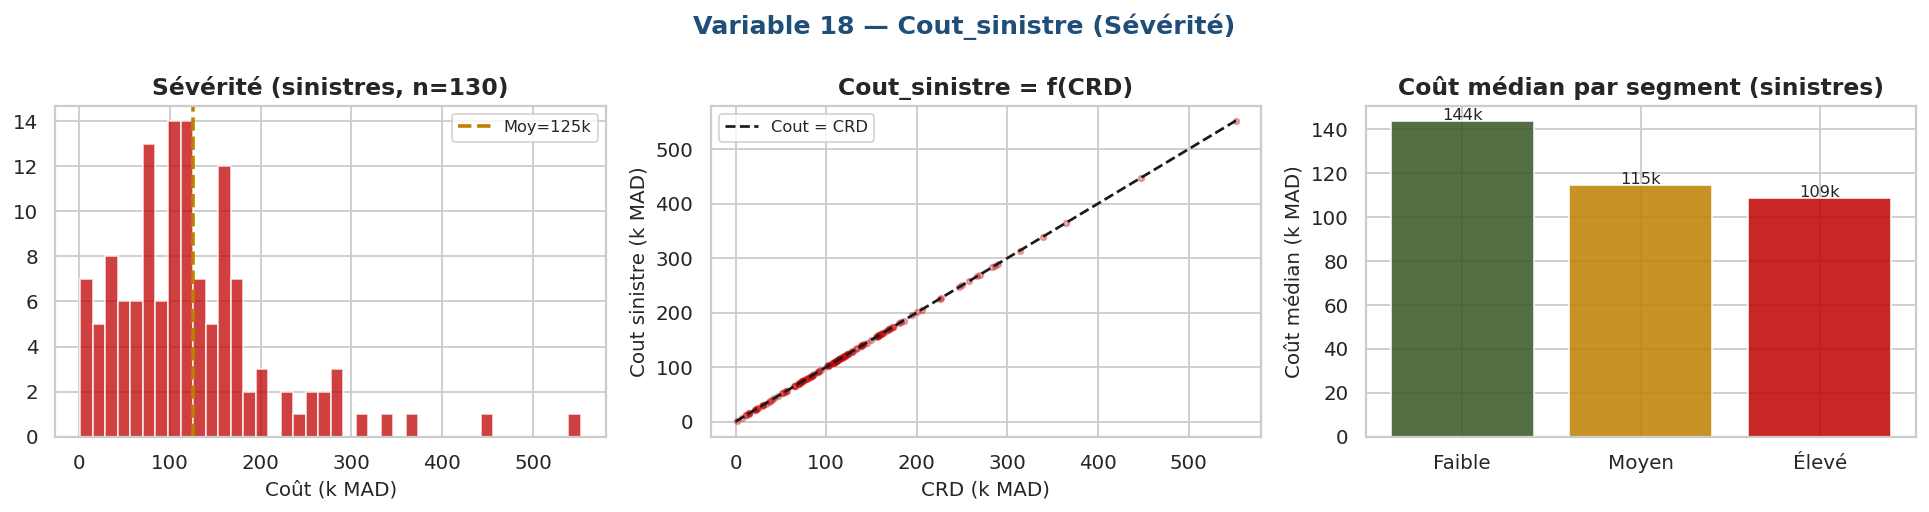


--- CORRÉLATION Cout_sinistre vs variables clés ---
Sinistre           0.8217
Prob_sinistre      0.1971
CRD                0.1914
Prop_remaining     0.1825
Contrat_actif      0.1189
Duree_credit       0.1002
Prime_mensuelle    0.0839
Montant_credit     0.0839


In [20]:
# ── Variable 18 : Cout_sinistre ───────────────────────────────────────────────
df['Cout_sinistre'] = df['Sinistre'] * df['CRD']

v_all     = df['Cout_sinistre']
v_sin     = df.loc[df['Sinistre'] == 1, 'Cout_sinistre']

print("=" * 55)
print("STATISTIQUES — Cout_sinistre (MAD)")
print("=" * 55)
print("Tous assurés (inclus 0) :")
print(v_all.describe(percentiles=[.5, .75, .90, .99]).round(0).to_string())
print(f"\nSinistres déclarés uniquement (n={len(v_sin)}) :")
print(v_sin.describe(percentiles=[.25, .5, .75, .90, .99]).round(0).to_string())
print(f"\nTotal coût sinistres : {v_all.sum()/1e6:.2f} M MAD")
print(f"Total primes         : {df['Total_primes'].sum()/1e6:.2f} M MAD")
sp_ratio = v_all.sum() / df['Total_primes'].sum()
print(f"Ratio S/P portefeuille : {sp_ratio*100:.1f}%  (benchmark ACAPS : 15–26%)")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Variable 18 — Cout_sinistre (Sévérité)", fontsize=14, fontweight='bold', color=BLUE)

# Distribution sévérité (sinistres uniquement)
axes[0].hist(v_sin / 1000, bins=40, color=RED, alpha=0.75, edgecolor='white')
axes[0].axvline(v_sin.mean() / 1000, color=AMBER, lw=2, ls='--',
                label=f'Moy={v_sin.mean()/1000:.0f}k')
axes[0].set_title(f"Sévérité (sinistres, n={len(v_sin)})")
axes[0].set_xlabel("Coût (k MAD)")
axes[0].legend(fontsize=9)

# Cout vs CRD
axes[1].scatter(df.loc[df['Sinistre']==1,'CRD'] / 1000,
                df.loc[df['Sinistre']==1,'Cout_sinistre'] / 1000,
                alpha=0.3, s=10, color=RED)
max_crd = df.loc[df['Sinistre']==1,'CRD'].max() / 1000
axes[1].plot([0, max_crd], [0, max_crd], 'k--', lw=1.5, label='Cout = CRD')
axes[1].set_title("Cout_sinistre = f(CRD)")
axes[1].set_xlabel("CRD (k MAD)")
axes[1].set_ylabel("Cout sinistre (k MAD)")
axes[1].legend(fontsize=9)

# Cout médian par segment de risque
cost_by_seg = df[df['Sinistre']==1].groupby('Risk_Segment', observed=True)['Cout_sinistre'].median() / 1000
bars = axes[2].bar(cost_by_seg.index, cost_by_seg.values,
                   color=colors_seg, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cost_by_seg.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}k', ha='center', fontsize=9)
axes[2].set_title("Coût médian par segment (sinistres)")
axes[2].set_ylabel("Coût médian (k MAD)")

plt.tight_layout()
plt.savefig('var18_cout_sinistre.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n--- CORRÉLATION Cout_sinistre vs variables clés ---")
num_cols = df.select_dtypes(include=np.number).columns.difference(['Cout_sinistre']).tolist()
corr = df[num_cols].corrwith(df['Cout_sinistre']).abs().sort_values(ascending=False).head(8).round(4)
print(corr.to_string())


---
## 📊 Section Finale — Matrice de Corrélation Globale & Feature Importance

### 🔢 Coefficient de Pearson
$$r_{XY} = \frac{\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum(X_i-\bar{X})^2 \sum(Y_i-\bar{Y})^2}}$$

Interprétation : |r| < 0.1 = négligeable | 0.1–0.3 = faible | 0.3–0.5 = modéré | > 0.5 = fort

### 📚 Références
- Pearson (1895), *Phil. Mag.*, 2(6), 559–572
- **Occam's Razor** en ML : éliminer les features redondantes (r > 0.85 entre deux features)


MATRICE DE CORRÉLATION GLOBALE (variables clés)


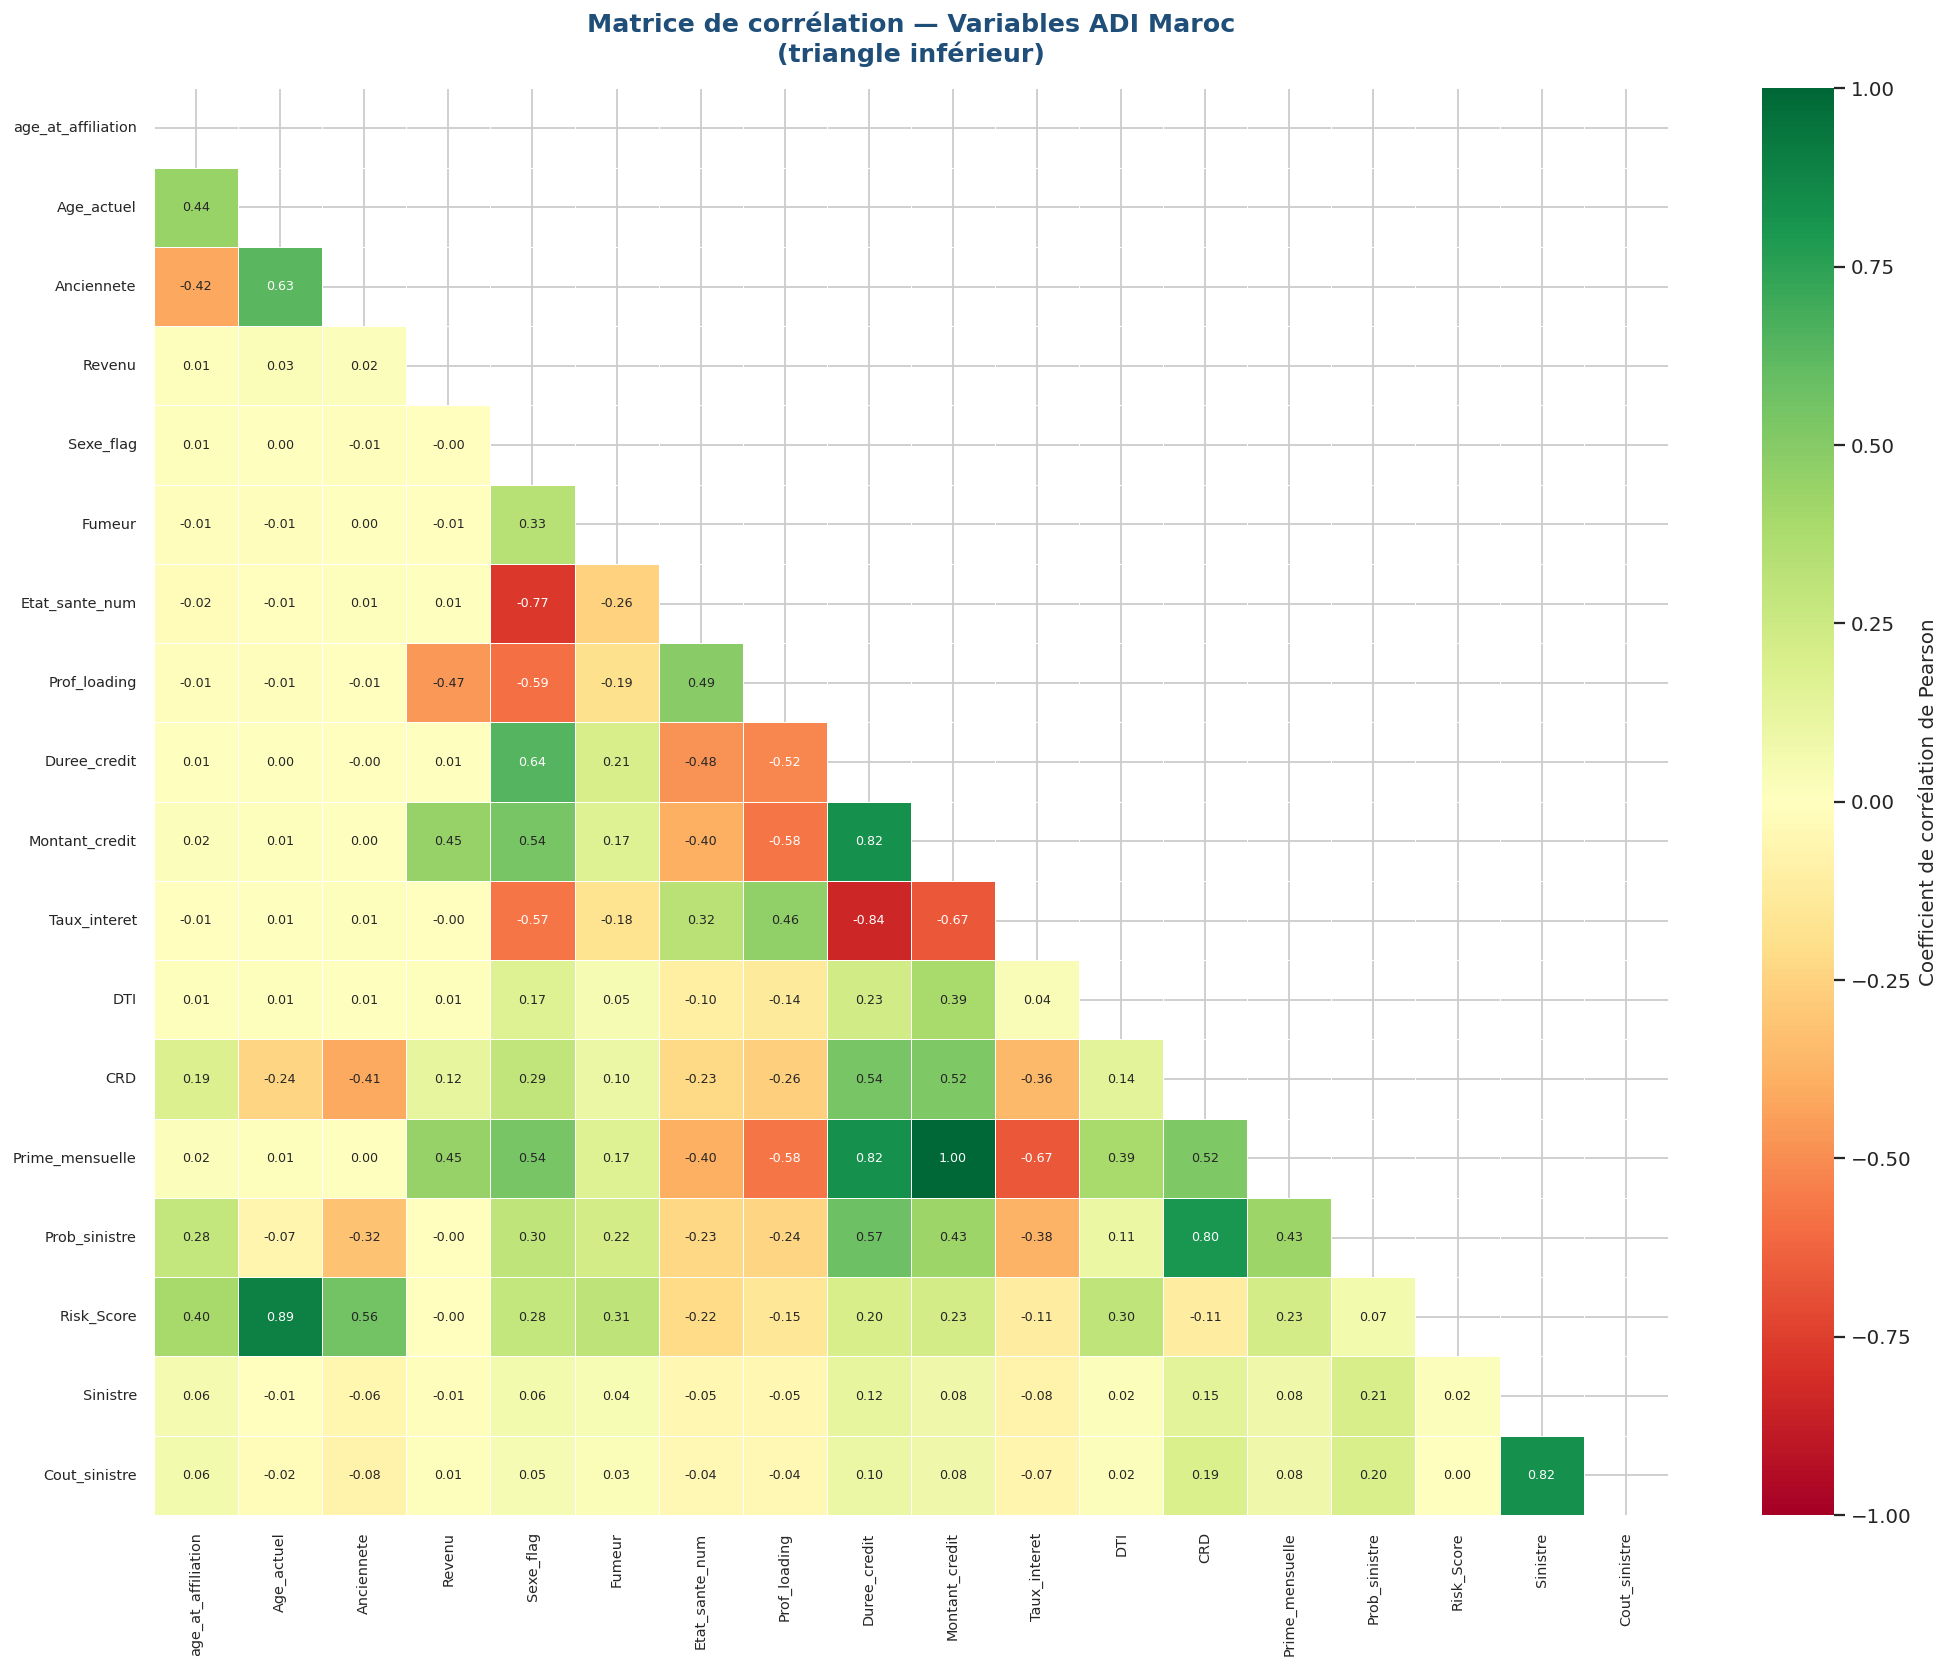

✅ Figure sauvegardée : correlation_matrix_globale.png

--- CORRÉLATIONS avec la variable cible SINISTRE (classées par |r|) ---
Cout_sinistre         0.822
Prob_sinistre         0.206
CRD                   0.147
Duree_credit          0.120
Taux_interet          0.081
Montant_credit        0.080
Prime_mensuelle       0.080
Sexe_flag             0.063
age_at_affiliation    0.058
Anciennete            0.056
Etat_sante_num        0.049
Prof_loading          0.048
Fumeur                0.042
Risk_Score            0.019
DTI                   0.016
Revenu                0.009
Age_actuel            0.005


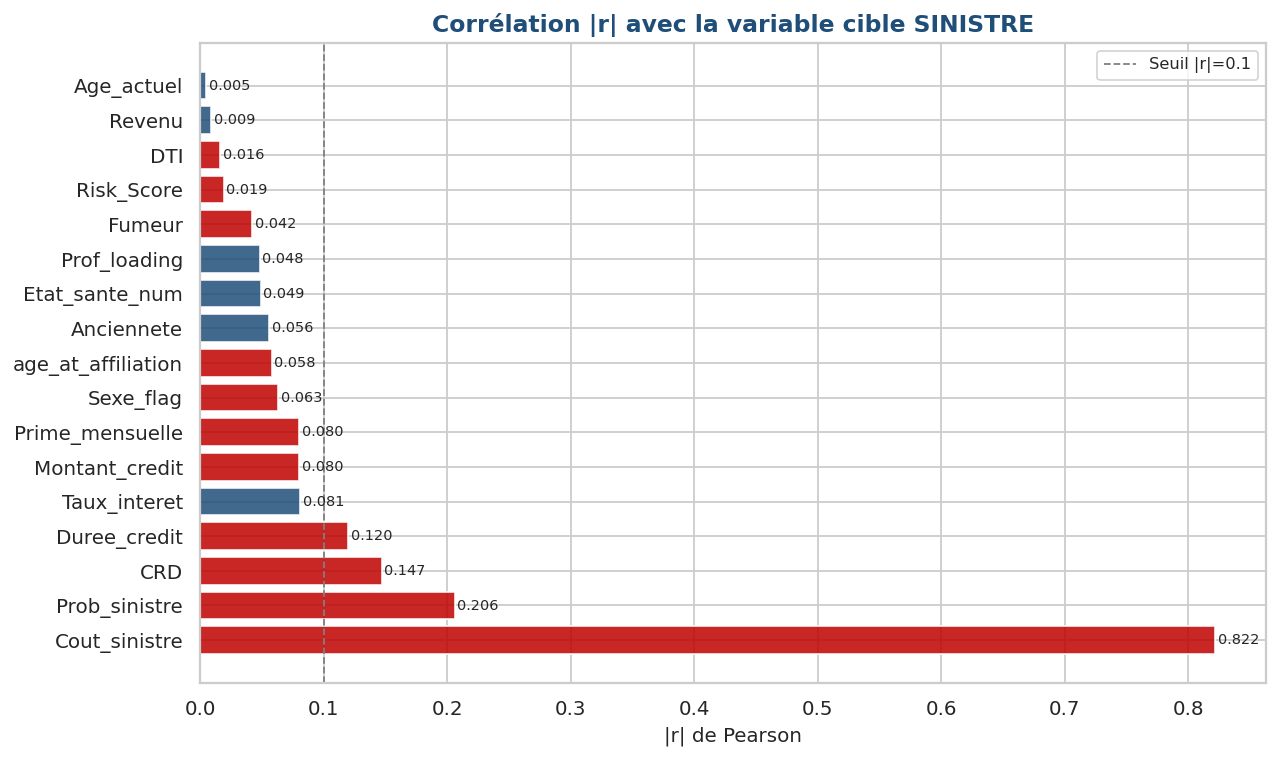

✅ Figure sauvegardée : correlation_sinistre.png

--- ALERTES MULTICOLINÉARITÉ (|r| > 0.85 entre features) ---
  ⚠️  Age_actuel             ↔ Risk_Score             : r=0.893
  ⚠️  Montant_credit         ↔ Prime_mensuelle        : r=1.000

✅ Analyse terminée. Dataset final enrichi :
   Lignes : 19,649  |  Colonnes : 34  |  Variables construites : 18


In [21]:
# ── Matrice de corrélation globale ────────────────────────────────────────────
num_features = [
    'age_at_affiliation', 'Age_actuel', 'Anciennete', 'Revenu',
    'Sexe_flag', 'Fumeur', 'Etat_sante_num', 'Prof_loading',
    'Duree_credit', 'Montant_credit', 'Taux_interet',
    'DTI', 'CRD', 'Prime_mensuelle',
    'Prob_sinistre', 'Risk_Score', 'Sinistre', 'Cout_sinistre'
]

# Filtrer les colonnes existantes
existing = [c for c in num_features if c in df.columns]
corr_matrix = df[existing].corr().round(3)

print("=" * 60)
print("MATRICE DE CORRÉLATION GLOBALE (variables clés)")
print("=" * 60)

# ── Figure principale : heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle masked

im = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    annot_kws={"size": 7},
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Coefficient de corrélation de Pearson'}
)
ax.set_title("Matrice de corrélation — Variables ADI Maroc\n(triangle inférieur)", 
             fontsize=14, fontweight='bold', color=BLUE, pad=15)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.savefig('correlation_matrix_globale.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Figure sauvegardée : correlation_matrix_globale.png")

# ── Corrélations avec la variable cible Sinistre ─────────────────────────────
print("\n--- CORRÉLATIONS avec la variable cible SINISTRE (classées par |r|) ---")
corr_sinistre = corr_matrix['Sinistre'].drop('Sinistre').abs().sort_values(ascending=False)
print(corr_sinistre.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [RED if v > 0 else BLUE for v in corr_matrix['Sinistre'].drop('Sinistre').reindex(corr_sinistre.index)]
bars = ax.barh(corr_sinistre.index, corr_sinistre.values, color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0.1, color='gray', lw=1, ls='--', label='Seuil |r|=0.1')
ax.set_title("Corrélation |r| avec la variable cible SINISTRE", fontsize=13, fontweight='bold', color=BLUE)
ax.set_xlabel("|r| de Pearson")
ax.legend(fontsize=9)
for bar, val in zip(bars, corr_sinistre.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('correlation_sinistre.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Figure sauvegardée : correlation_sinistre.png")

# ── Alerte multicolinéarité ───────────────────────────────────────────────────
print("\n--- ALERTES MULTICOLINÉARITÉ (|r| > 0.85 entre features) ---")
for i in range(len(existing)):
    for j in range(i+1, len(existing)):
        if abs(corr_matrix.iloc[i, j]) > 0.85 and existing[i] != 'Sinistre' and existing[j] != 'Sinistre':
            print(f"  ⚠️  {existing[i]:22s} ↔ {existing[j]:22s} : r={corr_matrix.iloc[i,j]:.3f}")

print("\n✅ Analyse terminée. Dataset final enrichi :")
print(f"   Lignes : {len(df):,}  |  Colonnes : {df.shape[1]}  |  Variables construites : {len(existing)}")


In [22]:
# ── Récapitulatif final du dataset enrichi ────────────────────────────────────
final_cols = [c for c in [
    'Code','DateNaissance','DateAffiliation','Situation_familiale','Revenu',
    'age_at_affiliation','Age_actuel','Anciennete','Sexe','Fumeur','Etat_sante',
    'Profession','Type_credit','Duree_credit','Taux_interet','Montant_credit',
    'DTI','CRD','Prime_mensuelle','Total_primes','Prob_sinistre',
    'Risk_Score','Risk_Segment','Sinistre','Cout_sinistre','Contrat_actif'
] if c in df.columns]

df_final = df[final_cols].copy()
print(f"Dataset final : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes")
print("\nColonnes :")
for c in df_final.columns:
    print(f"  {c:25s} | {str(df_final[c].dtype):15s} | exemple : {df_final[c].iloc[0]}")
df_final.head(5)


Dataset final : 19,649 lignes × 26 colonnes

Colonnes :
  Code                      | Int64           | exemple : 1
  DateNaissance             | datetime64[ns]  | exemple : 1970-10-19 00:00:00
  DateAffiliation           | datetime64[ns]  | exemple : 1998-09-01 00:00:00
  Situation_familiale       | object          | exemple : M
  Revenu                    | int64           | exemple : 3000
  age_at_affiliation        | float64         | exemple : 27.87
  Age_actuel                | int64           | exemple : 54
  Anciennete                | float64         | exemple : 26.34
  Sexe                      | object          | exemple : H
  Fumeur                    | int64           | exemple : 0
  Etat_sante                | object          | exemple : Bon
  Profession                | object          | exemple : Employé privé
  Type_credit               | object          | exemple : Immobilier
  Duree_credit              | int64           | exemple : 25
  Taux_interet              | fl

,Code,DateNaissance,DateAffiliation,Situation_familiale,Revenu,age_at_affiliation,Age_actuel,Anciennete,Sexe,Fumeur,...,DTI,CRD,Prime_mensuelle,Total_primes,Prob_sinistre,Risk_Score,Risk_Segment,Sinistre,Cout_sinistre,Contrat_actif
0,1,1970-10-19,1998-09-01,M,3000,27.87,54,26.34,H,0,...,0.3547,0.0,66.53,19959.00,0.0,0.803926,Élevé,0,0.0,0
1,2,1980-12-15,2008-09-10,C,5000,27.74,44,16.31,F,0,...,0.2900,0.0,17.47,628.92,0.0,-0.198775,Faible,0,0.0,0
2,3,1981-02-05,2005-08-18,M,4000,24.53,43,19.37,F,0,...,0.3378,0.0,33.08,2778.72,0.0,-0.185569,Faible,0,0.0,0
3,4,1977-05-16,2005-08-18,C,6000,28.26,47,19.37,H,1,...,0.3905,0.0,56.87,4777.08,0.0,0.604178,Élevé,0,0.0,0
4,5,1983-04-23,2009-11-01,M,8000,26.53,41,15.17,H,0,...,0.3182,0.0,120.05,21609.00,0.0,-0.240694,Faible,0,0.0,0


In [23]:
#save final dataset
df_final.to_csv('dataset_Sinistre.csv', index=False)
print("\n✅ Dataset final sauvegardé : dataset_Sinistre.csv")


✅ Dataset final sauvegardé : dataset_Sinistre.csv
